# 019. ViT と画像パッチ埋め込み / Vision Transformer and Patch Embedding

## 1. 概要 / Overview

ViT(Vision Transformer)は、画像を $P \times P$ 画素の重ならないパッチに分割し、各パッチを線形射影したベクトルの系列を、
言語モデルと同じ Transformer の encoder に入力して画像を分類するモデルである(Dosovitskiy et al. [1])。畳み込みニューラル
ネットワーク(CNN: Convolutional Neural Network)が構造として持つ局所性・並進等変性(translation equivariance)を持たない代わりに、
パッチどうしの関係をすべて注意機構(Attention Mechanism)で学習する。本トピックでは、パッチ埋め込み(Patch Embedding)・
[CLS] トークン・位置埋め込み(Position Embedding)を備えた ViT をスクラッチ実装し、CIFAR-10 [8] 上で、(A)位置埋め込みを除くと
正解率が下がるか、(B)パッチを小さくして系列を長くするほど正解率が上がるか、(C)データ量を減らしたときの正解率の低下が
ViT の方が CNN(ResNet-56 [7])より大きいか、を検証する。

### 1.1 実行の手順

本番実行は Google Colab T4 の **1 つのセッションで完結** させる。5.1 節のセットアップセルで`SMOKE_TEST = False`にして、
「すべてのセルを実行」する。

実行時間の予算は 1 セッションあたり **T4 で 120 分** とする。学習を始める前に(6.4 節)、T4 上でのスケーリングの計測(6.3 節)から、
学習ステップ数 $T$ の候補 $\{3968, 1984, 992\}$ と **削る段階** 0〜3 を組み合わせた 12 通りの **実行計画**(6.1 節)のそれぞれについて
残りの実行時間を見積もり、予算に収まる計画のうち優先順位の最も高いもの($T$ が大きいものを優先)を自動で選ぶ。選択は見積もりのみに
基づき、どの実験の結果も参照しない。最も軽い計画でも予算を超える場合は、学習の前に例外で停止する。**選ばれた計画・$T$・段階は
6.4 節の出力に印字される。** 本番の Colab での実行はこの 1 回だけで、事前の計測のための実行やセッションの分割はしない。

本トピックで学習したモデルは Hugging Face Hub にアップロードしない。020(CLIP)は画像とテキストの encoder を共同で学習するので、
019 からはコード(`VisionTransformer`)のみを再利用する。

## 2. 参考論文 / References

1. Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M.,
   Heigold, G., Gelly, S., Uszkoreit, J., Houlsby, N.,
   "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale", ICLR 2021.
   https://arxiv.org/abs/2010.11929(本トピックの原典。3.2〜3.5 節、実験 A〜C)
2. Touvron, H., Cord, M., Douze, M., Massa, F., Sablayrolles, A., Jégou, H.,
   "Training data-efficient image transformers & distillation through attention", ICML 2021.
   https://arxiv.org/abs/2012.12877(DeiT。3.5 節、位置づけのみ)
3. Beyer, L., Zhai, X., Kolesnikov, A., "Better plain ViT baselines for ImageNet-1k", arXiv 2022.
   https://arxiv.org/abs/2205.01580(2 次元正弦波の位置埋め込み、大域平均プーリング。3.3・3.4 節、実験 A の条件 2)
4. Cordonnier, J.-B., Loukas, A., Jaggi, M., "On the Relationship between Self-Attention and Convolutional Layers",
   ICLR 2020. https://arxiv.org/abs/1911.03584(多頭自己注意による畳み込みの表現。3.5 節)
5. Raghu, M., Unterthiner, T., Kornblith, S., Zhang, C., Dosovitskiy, A.,
   "Do Vision Transformers See Like Convolutional Neural Networks?", NeurIPS 2021.
   https://arxiv.org/abs/2108.08810(下位層の注意の局所性。3.6 節、位置づけのみ)
6. Liu, Z., Lin, Y., Cao, Y., Hu, H., Wei, Y., Zhang, Z., Lin, S., Guo, B.,
   "Swin Transformer: Hierarchical Vision Transformer using Shifted Windows", ICCV 2021.
   https://arxiv.org/abs/2103.14030(階層型の ViT。3.6 節、位置づけのみ)
7. He, K., Zhang, X., Ren, S., Sun, J., "Deep Residual Learning for Image Recognition", CVPR 2016.
   https://arxiv.org/abs/1512.03385(比較対象の CNN。4.2 節の CIFAR-10 用の構成で 56 層の ResNet-56。実験 C)
8. Krizhevsky, A., "Learning Multiple Layers of Features from Tiny Images", Technical Report, University of Toronto, 2009.
   https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf(CIFAR-10)

本文で用いる既存トピックの部品: 多頭注意機構(Multi-Head Attention)と Encoder Block は
[001](../01_foundations/001_attention_mechanism.ipynb)・[002](../01_foundations/002_transformer_block.ipynb)、位置エンコーディング
(Positional Encoding)は [003](../01_foundations/003_positional_encoding_rope.ipynb)、GELU は
[004](../01_foundations/004_normalization_and_activation.ipynb)、AdamW・warmup + cosine・gradient clipping は
[007](../02_pretraining/007_training_stabilization.ipynb)、混合精度学習は
[011](../03_efficient_training/011_mixed_precision_training.ipynb)、位置補間(Position Interpolation)は
[015](../03_efficient_training/015_long_context_extension.ipynb) で扱った。

## 3. 理論 / Theory

### 3.1 動機: Transformer を画像にそのまま使うと系列が長すぎる

002 の Transformer の encoder は、長さ $n$ のトークンの系列を入力とし、自己注意で全トークンの組の関係を計算する。自己注意の
計算量は系列長の 2 乗 $O(n^2 D)$ に比例する($D$ は隠れ次元)。画像の画素を 1 つずつトークンにすると、$H \times W$ 画素の画像は
長さ $HW$ の系列になる。CIFAR-10 の $32 \times 32$ でも $n = 1024$、ImageNet で標準的な $224 \times 224$ では $n = 50176$ であり、
注意の重みの行列($n \times n$)だけで 1 層・1 ヘッドあたり約 25 億要素になる。

ViT [1] は、画像を $P \times P$ のパッチにまとめてから 1 つのトークンにすることで、系列長を $1/P^2$ に縮める。原論文の題名
「16x16 Words」は、$224 \times 224$ の画像を $P = 16$ のパッチ $14 \times 14 = 196$ 個(= 196 語の文)として扱うことを指す。
それ以外の構造は言語の Transformer の encoder とほぼ同じであり、画像に固有の構造(近い画素ほど関係が強いこと、物体が
画像のどこにあっても同じ物体であること)を、アーキテクチャに組み込まずにデータから学習させる点に特徴がある(3.5 節)。

### 3.2 パッチ分割とパッチ埋め込み

**記号**:

- $x \in \mathbb{R}^{H \times W \times C}$: 入力画像($H$・$W$ は高さ・幅の画素数、$C$ はチャネル数。CIFAR-10 では $H = W = 32$、$C = 3$)。
- $P$: パッチの一辺の画素数。$H$・$W$ は $P$ で割り切れるとする。
- $N = HW / P^2$: パッチの数(系列長。[CLS] トークンを除く)。
- $x_p^i \in \mathbb{R}^{P^2 C}$: $i$ 番目のパッチを平坦化したベクトル($i = 1, \dots, N$、ラスタ順)。
- $D$: 埋め込みの次元(Transformer の $d_{\mathrm{model}}$)。
- $E \in \mathbb{R}^{(P^2 C) \times D}$: パッチ埋め込みの射影行列。
- $x_{\mathrm{class}} \in \mathbb{R}^{D}$: 学習可能な [CLS] トークン。$E_{\mathrm{pos}} \in \mathbb{R}^{(N+1) \times D}$: 位置埋め込み(3.4 節)。

**入力の系列**(原論文の式 1): パッチを射影し、先頭に [CLS] トークンを付け、位置埋め込みを加える。

$$
z_0 = [x_{\mathrm{class}};\ x_p^1 E;\ x_p^2 E;\ \dots;\ x_p^N E] + E_{\mathrm{pos}}
$$

**Encoder**(式 2・3): 002 の正規化前置(Pre-Layer Normalization)の Encoder Block を $L$ 層積む。$\mathrm{MSA}$ は多頭自己注意、
$\mathrm{LN}$ は層正規化(Layer Normalization)、$\mathrm{MLP}$ は GELU を活性化とする 2 層の順伝播ネットワーク(Feed-Forward Network、
中間層の次元 $d_{\mathrm{ff}}$)である($\ell = 1, \dots, L$)。

$$
z'_\ell = \mathrm{MSA}(\mathrm{LN}(z_{\ell-1})) + z_{\ell-1}, \qquad
z_\ell = \mathrm{MLP}(\mathrm{LN}(z'_\ell)) + z'_\ell
$$

**出力**(式 4): 最終層の [CLS] トークンの位置の表現 $z_L^0$ を正規化し、分類ヘッド(線形層 $W_{\mathrm{head}} \in \mathbb{R}^{D \times K}$、
$K$ はクラス数)で logits にする。

$$
y = \mathrm{LN}(z_L^0), \qquad \mathrm{logits} = y W_{\mathrm{head}} + b_{\mathrm{head}}
$$

```mermaid
flowchart LR
    img["画像 H x W x C"] --> split["P x P のパッチに分割<br/>N = HW / P^2 個"]
    split --> flat["平坦化<br/>x_p^i (P^2 C 次元)"]
    flat --> proj["線形射影 E<br/>(カーネル幅・stride P の畳み込みと等価)"]
    cls["[CLS] トークン x_class"] --> cat["先頭に連結<br/>(N+1) x D"]
    proj --> cat
    cat --> add["+ 位置埋め込み E_pos"]
    add --> enc["Encoder Block x L<br/>(正規化前置・多頭自己注意・GELU)"]
    enc --> pick["[CLS] の位置 z_L^0"]
    pick --> ln["最終の層正規化"]
    ln --> head["分類ヘッド(線形層)"]
    head --> logits["logits(K クラス)"]
```

#### 3.2.1 パッチ埋め込みは stride $P$ の畳み込みと等価である

チャネル $c$、行 $u$、列 $v$ の画素を $x_{c,u,v}$ と書く。出力チャネル数 $D$、カーネル幅 $P$、stride $P$ の畳み込み
(重み $W \in \mathbb{R}^{D \times C \times P \times P}$、バイアス $b \in \mathbb{R}^D$)の出力は、出力の格子の位置 $(r, s)$
($r, s = 0, \dots, H/P - 1$)とチャネル $d$ について

$$
o_{d,r,s} = b_d + \sum_{c=1}^{C} \sum_{u=0}^{P-1} \sum_{v=0}^{P-1} W_{d,c,u,v}\, x_{c,\, rP+u,\, sP+v}
$$

である。stride がカーネル幅に等しいので、出力の各位置が参照する画素の範囲 $\{rP, \dots, rP+P-1\} \times \{sP, \dots, sP+P-1\}$ は
ちょうど 1 つのパッチであり、異なる出力位置の範囲は重ならない。そこで、パッチ $(r, s)$ を添字 $(c, u, v)$ の順に平坦化した
ベクトルを $x_p^{(r,s)} \in \mathbb{R}^{P^2 C}$ とし、$E_{(c,u,v),\, d} = W_{d,c,u,v}$ と置くと、

$$
o_{:,r,s} = x_p^{(r,s)} E + b
$$

となり、パッチ埋め込みと一致する。平坦化の順序を原論文の $(u, v, c)$ に変えることは $E$ の行の並べ替えにすぎず、表現できる
写像は変わらない。実装(`PatchEmbedding`)は畳み込み`nn.Conv2d(C, D, kernel_size=P, stride=P)`で行い、平坦化 + 行列積と数値的に
一致することを 5.4 節で確かめる。パッチが重ならないことが本質であり、パッチ埋め込み自体は画素の近さについて何も仮定しない
(パッチの中の $P^2 C$ 個の値を任意の線形写像で混ぜる)。

#### 3.2.2 系列長と計算量

[CLS] トークンを含む系列長を $n = N + 1$ とする。1 層の順伝播の浮動小数点演算数(積和を 2 回と数える)は、線形層
(Query・Key・Value・出力の射影 $4D^2$ と順伝播ネットワーク $2 D d_{\mathrm{ff}}$)が $2n(4D^2 + 2Dd_{\mathrm{ff}})$、注意の行列積
($QK^\top$ と重み × Value)が $4n^2 D$ である。

$$
F_{\mathrm{layer}}(n) = 2n(4D^2 + 2Dd_{\mathrm{ff}}) + 4n^2 D, \qquad
\frac{4n^2 D}{2n(4D^2 + 2Dd_{\mathrm{ff}})} = \frac{n}{2D + d_{\mathrm{ff}}}
$$

右の比は、注意の行列積が線形層に対してどれだけの計算を占めるかを表す。本トピックの標準の ViT($D = 192$、$d_{\mathrm{ff}} = 768$、
$2D + d_{\mathrm{ff}} = 1152$)では次のようになる。

| $P$ | $N$ | $n$ | 注意の行列積 / 線形層 | 1 層の計算量($P = 4$ を 1 とする) |
|---|---|---|---|---|
| 8 | 16 | 17 | 0.015 | 0.25 |
| 4 | 64 | 65 | 0.056 | 1 |
| 2 | 256 | 257 | 0.22 | 4.5 |
| 1(画素単位) | 1024 | 1025 | 0.89 | 22.9 |

$P$ を半分にすると $N$ は 4 倍になり、計算量は線形層の分だけで 4 倍、注意の分は 16 倍になる。したがって、学習ステップ数を
揃えても、$P$ の小さい条件は 1 ステップあたり多くの計算をする(実験 B の交絡、6.1 節)。

### 3.3 分類の読み出し: [CLS] トークンと大域平均プーリング

画像全体の表現を 1 つのベクトルにする方法として、次の 2 つがある。

- **[CLS] トークン**(原論文の既定、BERT に倣う): 学習可能なベクトル $z_0^0 = x_{\mathrm{class}}$ を系列の先頭に置き、最終層の同じ位置の
  表現 $y = \mathrm{LN}(z_L^0)$ を使う。[CLS] トークン自身は画像の情報を持たず、各層の自己注意でパッチから情報を集める。
- **大域平均プーリング**(Global Average Pooling): [CLS] トークンを置かず、最終層のパッチの表現の平均を使う。Beyer et al. [3] の
  実装では、最終の層正規化の後に平均する。

$$
y_{\mathrm{avg}} = \frac{1}{N} \sum_{i=1}^{N} \mathrm{LN}(z_L^i)
$$

原論文(付録 D.3)は、両者の性能は学習率を別々に調整すれば同程度であると報告している。CNN の分類器は、最終の特徴マップに
大域平均プーリングを掛けるのが標準である(ResNet [7])。どちらの読み出しも、パッチの並べ替えに対して不変な集約である
(和は順序によらず、[CLS] トークンは自己注意で全パッチを集合として見る。3.4.2 節)。本トピックの実験は [CLS] トークンを
標準とし、大域平均プーリングは理論として扱うのみとする。

### 3.4 位置埋め込み(Position Embedding)

#### 3.4.1 2 つの方式

- **学習可能な 1 次元の位置埋め込み**(原論文の既定): $E_{\mathrm{pos}} \in \mathbb{R}^{(N+1) \times D}$ を学習可能なパラメータとし、
  $z_0$ に加える(式 1)。パッチはラスタ順に 1 列に並べるので、埋め込みの添字は 1 次元の位置 $i = 0, \dots, N$ である。
  **格子の構造(どのパッチが上下左右に隣り合うか)は与えない**。原論文の図 7(中央)は、学習後の埋め込みの余弦類似度が、同じ行・
  同じ列のパッチどうしで高くなる 2 次元の構造を示し、この構造がデータから学習されることを報告している。
- **2 次元正弦波の位置埋め込み**(Beyer et al. [3]): 格子上の行 $r$・列 $c$($0 \le r, c < \sqrt{N}$)のパッチに、$k = 0, \dots, D/4 - 1$
  の周波数 $\omega_k = 10000^{-k / (D/4 - 1)}$ を使って

$$
p_{r,c} = [\sin(c\,\omega);\ \cos(c\,\omega);\ \sin(r\,\omega);\ \cos(r\,\omega)] \in \mathbb{R}^{D}
$$

  を割り当てる($\sin(c\,\omega)$ は $D/4$ 個の周波数それぞれの値を並べたベクトルで、各ブロックが $D/4$ 次元。学習しない)。$\sin a \sin b + \cos a \cos b = \cos(a - b)$ より、2 つのパッチの埋め込みの
  内積は

$$
p_{r,c}^\top p_{r',c'} = \sum_{k} \cos\big((c - c')\,\omega_k\big) + \sum_{k} \cos\big((r - r')\,\omega_k\big)
$$

  となり、行の差と列の差だけで決まる。格子の構造を与える方式である。[CLS] トークンには位置がないので、本実装では
  零ベクトルを加える。

003 との違い: 003 は 1 次元の系列(文)の位置を扱い、隣り合うトークンは位置の差 1 の 2 つだけだった。画像のパッチは 2 次元の
格子に並び、ラスタ順の 1 次元の添字では、同じ列で縦に隣り合うパッチの添字の差が $\sqrt{N}$ になる(例: $N = 64$ なら 8)。学習可能な
1 次元の埋め込みはこの対応を知らずに学習する必要があり、2 次元正弦波の埋め込みは最初から与える。原論文(付録 D.4)は、位置埋め込み
なしが明確に劣り、1 次元・2 次元・相対位置の方式どうしの差は小さかったと報告している。

#### 3.4.2 位置埋め込みがなければ、出力はパッチの並べ替えに対して不変である

**主張**: $E_{\mathrm{pos}} = 0$ のとき、[CLS] トークンによる読み出しの logits は、パッチの任意の並べ替えに対して変わらない。

**記号**: パッチの並べ替え $\pi$($\{1, \dots, N\}$ の置換)に対し、系列の行を並べ替える置換行列 $\Pi \in \{0, 1\}^{(N+1) \times (N+1)}$ を、
[CLS] の位置 0 を動かさず($\Pi_{00} = 1$)、パッチの行 $i$ を $\pi(i)$ に移すものとする。系列の行列を $Z \in \mathbb{R}^{(N+1) \times D}$ と書く。

**証明**: Encoder Block を $f$ と書き、$f(\Pi Z) = \Pi f(Z)$(置換同変性)を示す。

1. 層正規化・順伝播ネットワーク・残差接続は、各行(トークン)に同じ関数を独立に掛けるので、行の並べ替えと交換する。
2. 自己注意: 1 つのヘッドで $Q = ZW^Q$、$K = ZW^K$、$V = ZW^V$ とする。入力が $\Pi Z$ なら $Q, K, V$ はそれぞれ $\Pi Q, \Pi K, \Pi V$ になり、
   スコアは $\Pi Q K^\top \Pi^\top / \sqrt{d_k}$ になる。行ごとの softmax は、行と列を同じ置換で並べ替えた行列に対して
   $\mathrm{softmax}(\Pi S \Pi^\top) = \Pi\, \mathrm{softmax}(S)\, \Pi^\top$ を満たす(各行の要素の集合が同じで、並びだけが変わる)。
   よって出力は $\Pi A \Pi^\top \Pi V = \Pi A V$($\Pi^\top \Pi = I$)であり、ヘッドの連結と出力の射影も行ごとなので、多頭自己注意も同変である。
3. 同変な関数の合成は同変なので、$L$ 層の Encoder 全体も $f_L \circ \dots \circ f_1(\Pi Z) = \Pi\, (f_L \circ \dots \circ f_1)(Z)$ を満たす。

$E_{\mathrm{pos}} = 0$ なら、パッチを $\pi$ で並べ替えた画像の $z_0$ は、元の $z_0$ を $\Pi$ で並べ替えたものに等しい([CLS] は
動かない)。3 より最終層の出力も $\Pi$ で並べ替わるだけであり、$\Pi$ は行 0 を動かさないので、$z_L^0$ と logits は変わらない。$\square$

位置埋め込みがあると、並べ替えた画像の入力は $\Pi X + E_{\mathrm{pos}}$($X$ はパッチ埋め込みの行列)になり、一般に
$\Pi(X + E_{\mathrm{pos}})$ と異なるので、不変性は成り立たない。位置埋め込みなしの ViT は、パッチの **集合**(bag of patches)の
分類器であり、パッチの中の画素の配置は見えるが、パッチどうしの配置は見えない。この不変性は 5.4 節で FP32 の数値として確かめる
(実験ではなく不変条件)。

#### 3.4.3 解像度を変えるときの 2 次元補間

事前学習より高い解像度で微調整すると、同じ $P$ ではパッチの数が $N = g^2$ から $N' = g'^2$ に増え($g$・$g'$ は格子の一辺)、
学習済みの $E_{\mathrm{pos}}$ の行数が足りなくなる。原論文(3.2 節)は、パッチ部分の埋め込みを $g \times g \times D$ の格子に並べ直し、
新しい格子の各点を元の画像の中での位置に写して **2 次元で補間** する。新しい格子の行 $r'$ の中心を元の格子の座標
$u = (r' + \tfrac{1}{2})\, g / g' - \tfrac{1}{2}$ に写し(列も同様)、周囲の 4 点(双線形)や 16 点(双 3 次)から値を作る。[CLS] の位置の
埋め込みはそのまま使う。

これは 015 の位置補間(Position Interpolation、Chen et al., arXiv 2023、https://arxiv.org/abs/2306.15595)と同じ考え方である。015 は RoPE の位置 $m$ を $m \cdot L / L'$ に
縮めて、学習した範囲の外へ外挿する代わりに範囲の内側を細かく使った。ViT の補間も、学習した格子の範囲の外に新しい位置を
作らず、範囲の内側を細かく分ける。違いは、RoPE の回転が位置の連続関数なので入力を縮めるだけで済むのに対し、学習可能な
位置埋め込みは離散の表なので、表の値の間を補間する必要がある点である。2 次元正弦波の埋め込みは連続関数なので、新しい格子の
座標をそのまま代入できる。本トピックは解像度を変えないので、補間は理論として扱うのみとする。

### 3.5 帰納バイアス(Inductive Bias)とデータ量

**CNN の帰納バイアス**: 畳み込み層は、(1)**局所性**: 各出力が入力の小さな近傍(カーネル幅 $k$ の窓)だけに依存し、(2)**重みの共有**
により **並進等変性** を持つ。入力を $t$ 画素ずらす作用素を $T_t$ と書くと、畳み込み $g$ について

$$
g(T_t x) = T_t\, g(x)
$$

が成り立つ(境界を除く)。物体が画像のどこにあっても同じ特徴が同じように検出されるという仮定を、パラメータの形そのものに
組み込んでいる。

**ViT の帰納バイアス**: ViT で画像の 2 次元構造を使うのは、パッチへの分割(と、解像度を変えるときの補間)だけである
(原論文 3.1 節)。自己注意は最初の層から全パッチの組を見るので局所性はなく、学習可能な位置埋め込みは初期状態で格子の構造を
持たない。並進についても、$P$ の整数倍のずらしに対してトークンが並べ替わるだけで、位置埋め込みが加わるので出力は等変にならない。
これらの構造はデータから学習する必要がある。

**自己注意は畳み込みを表現しうる**: Cordonnier et al. [4] は、$N_h$ 個のヘッドを持つ多頭自己注意が、相対位置の符号化を
使えば、カーネル幅 $\sqrt{N_h} \times \sqrt{N_h}$ の任意の畳み込み層を表現できることを示した(定理 1)。構成は、各ヘッドが 1 つの
相対位置 $\Delta$(カーネルの 1 つの要素)の近傍だけに注意を集中させ(注意の重みがその位置で 1 になる極限)、ヘッドごとの
Value の射影がその要素の重みを担う、というものである。したがって ViT は CNN を包含しうるが、それは(1)十分な数のヘッドと
適切な位置の符号化があり、(2)学習がその構成にたどり着く場合に限る。本トピックの ViT はヘッド数 $h = 3$ で、$3 \times 3$ の畳み込み
(9 ヘッドが必要)をこの構成でそのまま表現することはできず、位置の符号化も絶対位置である。表現しうることと、有限のデータで
学習によって獲得することは別の問題である。

**データ量とともに ViT が CNN を追い越す**: 原論文は、事前学習のデータ量を変えて ViT と ResNet(BiT)を比べた。ImageNet-1k
(約 130 万枚)で事前学習すると、大きな ViT は ResNet に劣るが、ImageNet-21k(約 1400 万枚)で並び、JFT-300M(約 3 億枚)では
上回った(図 3)。JFT の 900 万・3000 万・9000 万・3 億枚の部分集合で学習した比較(図 4)でも、小さい部分集合では ResNet が、
大きい部分集合では ViT が優れていた。原論文は、畳み込みの帰納バイアスは小さなデータでは有利だが、大きなデータでは
関連するパターンをデータから直接学習すれば足り、むしろ有益である、と解釈している。

**本トピックでの検証の形**: CIFAR-10(訓練 5 万枚)は原論文の最小の比較よりさらに 1〜2 桁小さく、ViT が CNN を追い越すことは
期待できない。そこで実験 C は絶対値の逆転ではなく、**データを減らしたときの正解率の落ち方(データ量の対数に対する傾き)が
ViT の方が大きいか** を検証する。帰納バイアスの弱いモデルほど、データ量への依存が強いという主張の、小規模な側での現れである。

**DeiT(位置づけのみ)**: Touvron et al. [2] は、強いデータ拡張(RandAugment・Mixup・CutMix など)と正則化、および CNN を教師と
する蒸留(蒸留トークンを追加する)により、ImageNet-1k だけで ViT を CNN と同程度まで学習できることを示した。データ量の不足を、
データ拡張と教師の知識で補う方法である。本トピックのデータ拡張は random crop と左右反転のみとし、DeiT の方法は使わない。

### 3.6 位置づけのみ扱うもの

- **ハイブリッド構成**(原論文 3.1 節): 画像のパッチの代わりに、CNN(ResNet)の中間の特徴マップを入力とし、特徴マップの
  $1 \times 1$ の各位置を 1 トークンとする。局所的な特徴抽出を畳み込みに任せ、大域的な関係を自己注意に任せる構成である。原論文では、
  計算量の小さい範囲でハイブリッドが純粋な ViT をわずかに上回り、大きなモデルでは差が消えた。
- **階層型の ViT**(Swin Transformer [6]): 小さなパッチから始めて、局所的な窓の中だけで自己注意を計算し(計算量が画像の大きさに
  線形)、層を進むごとに隣接するパッチを結合して解像度を下げる(CNN と同じ多段の特徴マップ)。隣り合う層で窓の位置をずらす
  (shifted window)ことで窓の間の情報を伝える。局所性と階層性という CNN の帰納バイアスを、自己注意の枠組みに戻した設計である。
- **下位層の注意の局所性**(Raghu et al. [5]): 学習済みの ViT では、下位層のヘッドの一部は近くのパッチに、一部は遠くのパッチに
  注意し、局所的な情報と大域的な情報を早い層から併せ持つ。十分なデータで学習した ViT の下位層は局所的な注意を学習する一方、
  データが少ないとその局所性が十分に学習されないと報告している。本トピックでは、注意の重みから計算する平均の注意距離
  (原論文の図 7 右)を、判定なしの観察として示す(6.8 節)。

### 3.7 アルゴリズム(擬似コード)

```
入力: 画像のバッチ x (B, C, H, W)、パッチサイズ P、位置埋め込みの方式
1. tokens = Conv2d(C, D, kernel=P, stride=P)(x)        # (B, D, H/P, W/P)
2. tokens = flatten + transpose(tokens)                 # (B, N, D)、ラスタ順
3. z = concat([x_class を B 個に複製, tokens], 系列方向)   # (B, N+1, D)
4. 方式が "learned" なら z += E_pos(学習可能)、"sinusoidal_2d" なら z += [0; p_(r,c)](固定)、"none" なら何もしない
5. for l = 1..L:
       z = z + MultiHeadAttention(LayerNormalization(z))    # 正規化前置
       z = z + FeedForwardNetwork(LayerNormalization(z))    # Linear -> GELU -> Linear
6. y = LayerNormalization(z[:, 0])                      # [CLS] の位置
7. logits = Linear(D, K)(y)                             # 分類ヘッド(零で初期化)
学習: 交差エントロピー損失、AdamW、warmup + cosine、gradient clipping、FP16 の autocast と動的損失スケーリング(CUDA のみ)
```

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装、本トピックで新規作成)**:

- `src/layers/patch_embedding.py`: `PatchEmbedding`(`nn.Conv2d(kernel_size=P, stride=P)`で実装し、平坦化 + 線形射影の形の重み
  $E$ を返す`linear_projection_weight()`を持つ)、`extract_patches()`(パッチの平坦化)、`permute_patches()`(パッチ単位の並べ替え)、
  `build_2d_sinusoidal_position_embedding()`(Beyer et al. の実装に従う)。
- `src/models/vit.py`: `VisionTransformer`。002 の`EncoderBlock`を`norm_first=True`で積層し、活性化は 004 の`gelu_exact`、
  正規化は`LayerNormalization`とする(原論文どおり)。位置埋め込みの方式を`"learned"`/`"sinusoidal_2d"`/`"none"`で切り替える。
  [CLS] トークンと最終正規化層を持ち、`forward(..., return_attention_weights=True)`で各層の注意の重みを返す。
  非埋め込みパラメータ数を数える`count_vit_non_embedding_parameters()`。
- `src/data/image.py`: CIFAR-10 の取得`load_cifar10()`(torchvision、キャッシュは`.cache/cifar10/`)、クラス均衡な検証集合の
  切り出し`split_class_balanced_validation()`、クラス均衡で入れ子の部分集合`make_nested_class_balanced_subsets()`、エポックの境界を
  またいで一定の大きさのバッチを切り出す`EpochShuffledBatchSampler`、GPU 上のデータ拡張`random_crop_and_flip()`。
- `src/training/classification.py`: 分類の学習ループ`train_image_classifier()`と評価`evaluate_image_classifier()`。007 の
  `AdamW`・`compute_warmup_cosine_learning_rate()`・gradient clipping、011 の`DynamicLossScaler`を使う。データの順序・データ拡張の
  乱数(CPU の生成器)と初期化の乱数を別々の生成器にする。

**ノートブック内に直接書く(019 固有)**:

- 比較対象の CNN: He et al. [7] の 4.2 節の CIFAR-10 用の構成(層数 $6n + 2$ で $n = 9$ の ResNet-56)を、ノートブック内に
  スクラッチ実装する(`CifarResNet`)。比較対象であって主題ではないので、共通モジュールにはしない。1 枚あたりの積和演算の数の
  閉形式が、モジュールのフックで数えた値と一致することを 5.4 節で確かめる。
- 各実験の条件の定義・学習率の較正・判定・可視化・スケーリングの計測、計算量の閉形式。

**既存モジュールの変更**: なし(`EncoderBlock`・`LayerNormalization`・`gelu_exact`・`AdamW`・
`compute_warmup_cosine_learning_rate()`・`DynamicLossScaler`はそのまま使う)。`DynamicLossScaler.unscale_gradients()`の代わりに、
同じ除算をまとめて行う`unscale_gradients_and_compute_norm()`を新しいモジュールに置いた理由は、そのモジュールの docstring と
5.4 節に記す(結果が bit 単位で一致することを確かめる)。

**アップロード方針**: Hugging Face Hub へのアップロードはしない。学習したモデルは条件比較のためのもので、後続のトピックの入力に
ならない(020 は画像とテキストの encoder を共同で学習するので、019 から再利用するのはコードのみ)。

**生成物の置き場所**:

| 生成物 | 置き場所 |
|---|---|
| CIFAR-10(torchvision が取得するアーカイブと展開したファイル) | `.cache/cifar10/`(入力から決定的に再生成できる。セッション内でのみ再利用する) |
| 検証集合・部分集合の添字、GPU 上の画像のテンソル | メモリ上のみ(固定のシードから決定的に再生成できる) |
| 学習したモデル | メモリ上のみ(評価の直後に破棄する) |
| 判定の記録 | 判定と前提条件を計算した各セルの出力 |

外部から取得するのは CIFAR-10 のみである(torchvision の`CIFAR10(download=True)`が
`https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz`から取得し、MD5 を照合する)。**torchvision の用途は CIFAR-10 の取得のみ**
であり、モデルの定義や学習済みの重みには使わない(CNN はノートブック内のスクラッチ実装)。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)

`SMOKE_TEST`(スモークテストか本番か)はこのセルでのみ切り替える。本トピックは Hub にアップロードしないので、アップロードの
フラグはない。

**混合精度**: FP16 の`torch.autocast`と動的損失スケーリング(011 の`DynamicLossScaler`)は CUDA のときのみ有効にする。MPS・CPU
では FP32 で学習する。実効の設定をこのセルで印字する。評価は常に FP32 で行う。

**決定性**: 本トピックでは`torch.use_deterministic_algorithms(True)`を使わない。畳み込みの速度のために
`torch.backends.cudnn.benchmark = True`とし、決定的な演算を強制しない。そのため、同じシードの学習を
繰り返しても、CUDA の演算の丸めの順序の違いで結果が bit 単位では一致しないことがある。条件間の対応付け(同じシードの条件どうしで
初期化・データの順序・データ拡張を揃えること)は乱数の生成器によって決まり、演算の決定性には依存しない。

In [1]:
# 環境セットアップ(Google Colab)
import os
import sys
import time

SMOKE_TEST = False  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)

NOTEBOOK_START_TIME = time.time()

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.isdir("/content/ai-theories"):  # 2 回目の実行では clone し直さない
        !git clone https://github.com/kojikojiprg/ai-theories.git /content/ai-theories
    %cd /content/ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt

# インストールで版が入れ替わったパッケージの古い版がメモリに残っていないかを、torch などを import する前に確かめる。
# Colab では食い違いがあればカーネルを終了する(再接続後、もう一度「すべてのセルを実行」する)
from src.utils.environment import check_preloaded_package_versions  # noqa: E402

check_preloaded_package_versions(on_mismatch="restart" if IN_COLAB else "raise")

import torch  # noqa: E402

from src.utils.environment import print_execution_environment  # noqa: E402

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
execution_environment = print_execution_environment(device)

# 混合精度(011): FP16 の autocast と動的損失スケーリングは CUDA のときのみ有効にする
USE_FP16_AUTOCAST = device.type == "cuda"
INIT_LOSS_SCALE = 2.0**16  # torch.amp.GradScaler の既定値と同じ
LOSS_SCALE_GROWTH_INTERVAL = 2000  # 同上
CNN_CHANNELS_LAST = device.type == "cuda"  # 畳み込みの高速化のためのメモリ配置(数値には影響しない)
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
print(
    f"SMOKE_TEST={SMOKE_TEST}、混合精度: FP16 autocast={USE_FP16_AUTOCAST}、"
    f"動的損失スケーリング={'有効' if USE_FP16_AUTOCAST else '無効(FP32)'}"
    f"(初期スケール {INIT_LOSS_SCALE:g}、growth_interval {LOSS_SCALE_GROWTH_INTERVAL}、backoff 0.5、growth 2.0)、"
    f"評価は FP32、CNN の channels_last={CNN_CHANNELS_LAST}、cudnn.benchmark={torch.backends.cudnn.benchmark}、"
    f"決定的な演算の強制: {torch.are_deterministic_algorithms_enabled()}"
)

/content/ai-theories
Using Python 3.13.15 environment at: /usr
Checked 60 packages in 104ms
読み込み済みのパッケージの版の検査(requirements.txt): 食い違いなし。検査した配布物 11 個(certifi==2026.7.22, cycler==0.12.1, fonttools==4.63.0, kiwisolver==1.5.0, matplotlib==3.11.1, numpy==2.5.2, packaging==26.3, pillow==12.3.0, pyparsing==3.3.2, python-dateutil==2.9.0.post0, six==1.17.0)、未読み込みのため検査しなかった配布物 44 個、__version__ がないため比べなかった配布物 0 個(なし)、表記の違いで誤検出するため比べなかった配布物 0 個(なし)
実行環境 / Execution environment
  Python                                 : 3.13.15
  OS / platform                          : Linux-6.6.122+-x86_64-with-glibc2.39
  torch                                  : 2.13.0+cu130
  torch のビルド時の CUDA                : 13.0
  cuDNN                                  : 92000
  デバイス / device                      : cuda
  GPU 名 / GPU name                      : Tesla T4
  compute capability                     : 7.5
  GPU の総メモリ (GiB)                   : 14.56
  コミット / git commit                  : 18e70af43b0eb0397b34f3fe004

In [2]:
import hashlib
import json
import math

import matplotlib.pyplot as plt
import numpy as np
from torch import nn
from torch.nn import functional

from src.data.image import (
    EpochShuffledBatchSampler,
    load_cifar10,
    make_nested_class_balanced_subsets,
    normalize_images,
    random_crop_and_flip,
    split_class_balanced_validation,
    to_normalized_float,
)
from src.layers.patch_embedding import (
    PatchEmbedding,
    extract_patches,
    permute_patches,
)
from src.models.vit import VisionTransformer, count_vit_non_embedding_parameters
from src.training.classification import (
    evaluate_image_classifier,
    logit,
    train_image_classifier,
    unscale_gradients_and_compute_norm,
)
from src.training.precision import DynamicLossScaler
from src.utils.statistics import fit_power_law_exponent


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def empty_device_cache() -> None:
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()


def timed_call(fn) -> float:
    sync_device()
    start = time.time()
    fn()
    sync_device()
    return time.time() - start


def sha256_of_tensor(tensor: torch.Tensor) -> str:
    return hashlib.sha256(tensor.detach().contiguous().cpu().numpy().tobytes()).hexdigest()


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各節で記録)

### 5.2 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所に集約する。

**縮小の規則**:

- 縮小するのは **学習ステップ数 $T$ の候補** と **シード数** のみとする。$T$ の候補は本番 $\{3968, 1984, 992\}$、スモークテスト
  $\{128, 64, 32\}$ で、どちらも公比 2 の 3 点であり、本番とスモークテストの比(31 倍)を候補の間で揃える。スケーリングの計測点は、
  候補の最大値 $T_{\max}$ の $T_{\max}/32, T_{\max}/16, T_{\max}/8$ とする(本番 124・248・496、スモークテスト 4・8・16)。
- **縮小しないもの**: データ(訓練 45,000 枚・検証 5,000 枚・テスト 10,000 枚の全件)、実験 B のパッチサイズの 3 水準
  $P \in \{8, 4, 2\}$、実験 C のデータ量の 3 水準 $f \in \{1/16, 1/4, 1\}$(公比 4)、モデルの構成、バッチサイズ、学習率の較正の格子
  と拡張の規則、学習率のスケジュールの形(warmup の比率・最小学習率の比率)、途中の評価の位置($T$ に対する比率)、実行計画の表の
  構造と優先順位、前提条件・判定の閾値。
- **シード数**: 本番は 5(削った段階で 3)。スモークテストは 3(削った段階で 2)とする。スモークテストでも「削る前 > 削った後
  $\ge 2$」の順序関係を保ち、計画を強制指定したスモークテストで、削る処理が実際にシード数を減らすことを確かめるためである。
  すべての水準で標準条件 S($P = 4$・学習可能な 1 次元・全データ)のシードを実験 A・B・C で共有する構造を保つ。
- **テスト専用の上書き**: 環境変数`AI_THEORIES_FORCE_PLAN`(0〜11)が設定されているときのみ、6.4 節で見積もりによる計画の選択の
  代わりにその計画を使う(スモークテストで各計画の経路を確かめるため)。本番では受け付けず、このセルで停止する。

In [3]:
# --- 全水準で共通の定数(本番実行前に宣言し、SMOKE_TEST で変えない) ---
IMAGE_SIZE, IN_CHANNELS, NUM_CLASSES = 32, 3, 10
D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF = 192, 6, 3, 768  # 標準の ViT
STANDARD_PATCH_SIZE = 4  # 標準条件 S(N = 64)
BATCH_SIZE = 128
WARMUP_RATIO = 0.1  # 最初の 10% のステップで線形 warmup
MIN_LEARNING_RATE_RATIO = 0.01  # cosine decay の下限 = 最大の学習率 x 0.01
WEIGHT_DECAY = 0.05  # 行列形の重みのみ(バイアス・正規化層・[CLS]・位置埋め込みには掛けない)
GRADIENT_CLIP_THRESHOLD = 1.0
CROP_PADDING = 4
VALIDATION_PER_CLASS = 500  # 検証集合 5,000 枚(クラス均衡)
DATA_FRACTIONS = (1 / 16, 1 / 4, 1.0)  # 実験 C のデータ量(入れ子、公比 4)
PATCH_SIZES = (8, 4, 2)  # 実験 B のパッチサイズ(N = 16, 64, 256)
POSITION_EMBEDDINGS = ("none", "learned", "sinusoidal_2d")  # 実験 A の条件 0, 1, 2
LR_GRID = {"vit": (5e-4, 1e-3, 2e-3), "cnn": (5e-4, 1e-3, 2e-3)}  # 学習率の較正の格子(公比 2)
LR_GRID_RATIO = 2.0
ACCURACY_MIN = 0.25  # 前提条件 P1: 一様な推測(0.1)の 2.5 倍
SIGMA_MULTIPLIER = 2.0  # 判定の閾値は対比量の標準偏差の 2 倍
INTERMEDIATE_EVAL_FRACTIONS = (0.25, 0.5, 0.75)  # 途中の検証集合の評価の位置(診断量、T に対する比率)
EVAL_BATCH_SIZE = 500
ATTENTION_DISTANCE_IMAGES = 1000  # 注意距離の観察に使う検証集合の画像の数

# 乱数シード(学習のシード s とは独立に固定するもの)
VALIDATION_SPLIT_SEED = 19_001
SUBSET_SEED = 19_002
PATCH_SHUFFLE_SEED = 19_003  # 位置情報への依存度の診断量で使うパッチの並べ替え
# 学習のシード s の初期化は torch.manual_seed(19100 + s)、データの順序・データ拡張は torch.Generator().manual_seed(19200 + s)
INIT_SEED_BASE = 19_100
DATA_SEED_BASE = 19_200
CALIBRATION_SEED_INDEX = 90  # 学習率の較正専用のシード(実験のシード 0〜4 と共有しない)
TIMING_SEED_INDEX = 91  # スケーリングの計測専用のシード
SESSION_BUDGET_SECONDS = 120 * 60  # 1 セッションの予算(T4 で 120 分)

# CIFAR-10 の内容の照合(torchvision が展開した配列の SHA-256。取得元が変わっていないことを確かめる)
CIFAR10_SHA256 = {
    "train_images": "9d5c2eddadb0deff02c14c350c0385aab7b1d5ff1edfeb4997c8dc8644960111",
    "train_labels": "f5cfe00b0f00968c0cc5ff3b1d2de51b10e33efa277c2986f4e0fa63e58c9f4f",
    "test_images": "177777c33ba79825320efa646ad04a94bdc3c80e4ebe3bd21724f8cdfd4b9d56",
    "test_labels": "cbb7365de8ed11f05cc4c3a1e7f78144127c5e851efd83762fb18202461230bb",
}

# 学習ステップ数 T の候補(公比 2、大きい順)。6.4 節で実行計画として自動選択する(6.1・6.2 節)
T_CANDIDATES = {
    "smoke": (128, 64, 32),
    "prod": (3968, 1984, 992),
}
# --- 削る段階(6.1 節)。順序: 実験 B の P = 2 -> 実験 C のシード数 -> 実験 A のシード数 ---
STAGES = {
    "prod": {
        0: {"SEEDS_A": 5, "SEEDS_B": 5, "SEEDS_C": 5, "B_PATCH_SIZES": (8, 4, 2)},
        1: {"SEEDS_A": 5, "SEEDS_B": 5, "SEEDS_C": 5, "B_PATCH_SIZES": (8, 4)},
        2: {"SEEDS_A": 5, "SEEDS_B": 5, "SEEDS_C": 3, "B_PATCH_SIZES": (8, 4)},
        3: {"SEEDS_A": 3, "SEEDS_B": 5, "SEEDS_C": 3, "B_PATCH_SIZES": (8, 4)},
    },
    "smoke": {  # 本番と同じ構造(シード数 5 -> 3 を 3 -> 2 に縮小)
        0: {"SEEDS_A": 3, "SEEDS_B": 3, "SEEDS_C": 3, "B_PATCH_SIZES": (8, 4, 2)},
        1: {"SEEDS_A": 3, "SEEDS_B": 3, "SEEDS_C": 3, "B_PATCH_SIZES": (8, 4)},
        2: {"SEEDS_A": 3, "SEEDS_B": 3, "SEEDS_C": 2, "B_PATCH_SIZES": (8, 4)},
        3: {"SEEDS_A": 2, "SEEDS_B": 3, "SEEDS_C": 2, "B_PATCH_SIZES": (8, 4)},
    },
}
SEED_KEYS = ("SEEDS_A", "SEEDS_B", "SEEDS_C")


def build_plans(level: str) -> list[dict]:
    # 実行計画: T の大きい順を第 1 キー、段階の番号の小さい順を第 2 キーとして番号を付ける(6.1 節)
    return [
        {"plan": i, "T": t, "stage": stage}
        for i, (t, stage) in enumerate((t, stage) for t in T_CANDIDATES[level] for stage in sorted(STAGES[level]))
    ]


PLANS = {level: build_plans(level) for level in T_CANDIDATES}

CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
FORCED_PLAN_VALUE = os.environ.get("AI_THEORIES_FORCE_PLAN")
if FORCED_PLAN_VALUE is not None and not SMOKE_TEST:
    raise RuntimeError(
        f"本番(SMOKE_TEST=False)では計画の強制(AI_THEORIES_FORCE_PLAN={FORCED_PLAN_VALUE!r})を受け付けない。"
        "環境変数を削除して再実行すること。"
    )
FORCED_PLAN = None if FORCED_PLAN_VALUE is None else int(FORCED_PLAN_VALUE)
assert FORCED_PLAN is None or 0 <= FORCED_PLAN < len(PLANS[CURRENT_LEVEL_NAME]), FORCED_PLAN

PROD_T_CANDIDATES = T_CANDIDATES["prod"]
T_MAX = T_CANDIDATES[CURRENT_LEVEL_NAME][0]
# TRAIN_STEPS(T)は 6.4 節で実行計画を選んだ後に決まる


def warmup_steps_for(num_steps: int) -> int:
    return max(1, round(WARMUP_RATIO * num_steps))


def intermediate_eval_steps_for(num_steps: int) -> tuple[int, ...]:
    return tuple(round(f * num_steps) for f in INTERMEDIATE_EVAL_FRACTIONS)


SCALING_STEP_COUNTS = (T_MAX // 32, T_MAX // 16, T_MAX // 8)

# --- 縮小規則と水準の構造の確認 ---
for _name, _candidates in T_CANDIDATES.items():
    assert _candidates[0] % 32 == 0, _name  # 計測点 T_max/32, T_max/16, T_max/8 が整数で公比 2
    assert len(_candidates) == 3 and all(a == 2 * b for a, b in zip(_candidates, _candidates[1:], strict=False))
    assert all(len(set(intermediate_eval_steps_for(t))) == 3 and warmup_steps_for(t) < t for t in _candidates)
    _plans = PLANS[_name]
    assert len(_plans) == 12 and [p["plan"] for p in _plans] == list(range(12))
    assert all(  # 優先順位: T の大きい順、同じ T では段階の小さい順
        (a["T"] > b["T"]) or (a["T"] == b["T"] and a["stage"] < b["stage"]) for a, b in zip(_plans, _plans[1:], strict=False)
    )
    _stages = STAGES[_name]
    assert set(_stages) == {0, 1, 2, 3}
    for _k in range(1, 4):  # 段階が上がるほど、どの量も減るか変わらない
        for _key in SEED_KEYS:
            assert _stages[_k][_key] <= _stages[_k - 1][_key]
        assert set(_stages[_k]["B_PATCH_SIZES"]) <= set(_stages[_k - 1]["B_PATCH_SIZES"])
    for _stage in _stages.values():
        assert min(_stage[k] for k in SEED_KEYS) >= 2
        assert STANDARD_PATCH_SIZE in _stage["B_PATCH_SIZES"] and len(_stage["B_PATCH_SIZES"]) >= 2
        assert set(_stage["B_PATCH_SIZES"]) <= set(PATCH_SIZES)
_ratios = {p / s for p, s in zip(T_CANDIDATES["prod"], T_CANDIDATES["smoke"], strict=True)}
assert len(_ratios) == 1 and _ratios.pop() > 1  # 本番とスモークテストの比が候補の間で揃う
assert [(p["T"] > 0, p["stage"]) for p in PLANS["prod"]] == [(p["T"] > 0, p["stage"]) for p in PLANS["smoke"]]
for _k in range(1, 4):  # 本番とスモークテストで、各段階で何が変わるかが同じ(構造を保つ縮小)
    for _key in (*SEED_KEYS, "B_PATCH_SIZES"):
        assert (STAGES["prod"][_k][_key] == STAGES["prod"][_k - 1][_key]) == (
            STAGES["smoke"][_k][_key] == STAGES["smoke"][_k - 1][_key]
        )
    assert STAGES["prod"][_k]["B_PATCH_SIZES"] == STAGES["smoke"][_k]["B_PATCH_SIZES"]
assert all(a / b == 2 for a, b in zip(PATCH_SIZES, PATCH_SIZES[1:], strict=False))  # N は公比 4
assert all(b / a == 4 for a, b in zip(DATA_FRACTIONS, DATA_FRACTIONS[1:], strict=False))
for _grid in LR_GRID.values():
    assert all(math.isclose(b / a, LR_GRID_RATIO) for a, b in zip(_grid, _grid[1:], strict=False))
assert D_MODEL % NUM_HEADS == 0 and D_MODEL % 4 == 0 and IMAGE_SIZE % max(PATCH_SIZES) == 0

print(
    f"水準 {CURRENT_LEVEL_NAME!r}: T の候補 {T_CANDIDATES[CURRENT_LEVEL_NAME]}(本番 {PROD_T_CANDIDATES})、"
    f"warmup {[warmup_steps_for(t) for t in T_CANDIDATES[CURRENT_LEVEL_NAME]]} ステップ"
)
print(
    f"ViT: D = {D_MODEL}、L = {NUM_LAYERS}、h = {NUM_HEADS}、d_ff = {D_FF}、標準の P = {STANDARD_PATCH_SIZE}、dropout なし、"
    f"位置埋め込みの条件 {POSITION_EMBEDDINGS}"
)
print(
    f"学習: バッチ {BATCH_SIZE}、AdamW(重み減衰 {WEIGHT_DECAY})、warmup {WARMUP_RATIO:.0%} + cosine(下限 x{MIN_LEARNING_RATE_RATIO})、"
    f"gradient clipping {GRADIENT_CLIP_THRESHOLD}、random crop(パディング {CROP_PADDING})+ 左右反転"
)
print(f"水準: P {PATCH_SIZES}、f {DATA_FRACTIONS}、学習率の格子 {LR_GRID}")
print(
    f"途中の評価のステップ(T の候補ごと) {[intermediate_eval_steps_for(t) for t in T_CANDIDATES[CURRENT_LEVEL_NAME]]}、"
    f"スケーリングの計測点 {SCALING_STEP_COUNTS} ステップ"
)
print(f"削る段階({CURRENT_LEVEL_NAME!r}): {json.dumps(STAGES[CURRENT_LEVEL_NAME])}")
print(f"実行計画({CURRENT_LEVEL_NAME!r}、6.4 節で選ぶ、番号の小さいほど優先):")
for _p in PLANS[CURRENT_LEVEL_NAME]:
    print(f"  計画 {_p['plan']:2d}: T = {_p['T']}、段階 {_p['stage']}")

水準 'prod': T の候補 (3968, 1984, 992)(本番 (3968, 1984, 992))、warmup [397, 198, 99] ステップ
ViT: D = 192、L = 6、h = 3、d_ff = 768、標準の P = 4、dropout なし、位置埋め込みの条件 ('none', 'learned', 'sinusoidal_2d')
学習: バッチ 128、AdamW(重み減衰 0.05)、warmup 10% + cosine(下限 x0.01)、gradient clipping 1.0、random crop(パディング 4)+ 左右反転
水準: P (8, 4, 2)、f (0.0625, 0.25, 1.0)、学習率の格子 {'vit': (0.0005, 0.001, 0.002), 'cnn': (0.0005, 0.001, 0.002)}
途中の評価のステップ(T の候補ごと) [(992, 1984, 2976), (496, 992, 1488), (248, 496, 744)]、スケーリングの計測点 (124, 248, 496) ステップ
削る段階('prod'): {"0": {"SEEDS_A": 5, "SEEDS_B": 5, "SEEDS_C": 5, "B_PATCH_SIZES": [8, 4, 2]}, "1": {"SEEDS_A": 5, "SEEDS_B": 5, "SEEDS_C": 5, "B_PATCH_SIZES": [8, 4]}, "2": {"SEEDS_A": 5, "SEEDS_B": 5, "SEEDS_C": 3, "B_PATCH_SIZES": [8, 4]}, "3": {"SEEDS_A": 3, "SEEDS_B": 5, "SEEDS_C": 3, "B_PATCH_SIZES": [8, 4]}}
実行計画('prod'、6.4 節で選ぶ、番号の小さいほど優先):
  計画  0: T = 3968、段階 0
  計画  1: T = 3968、段階 1
  計画  2: T = 3968、段階 2
  計画  3: T = 3968、段階 3
  計画  4: T = 1984、段階 0
  計画  5: T = 1984、段階 1
  計

### 5.3 データ: CIFAR-10 の取得・分割・部分集合

- CIFAR-10 を torchvision で取得し(キャッシュ`.cache/cifar10/`)、展開した配列の SHA-256 を 5.2 節の定数と照合する。
- 訓練集合 50,000 枚から、クラス均衡な **検証集合 5,000 枚**(各クラス 500 枚、乱数シード`19001`)を切り出す。残る 45,000 枚が
  学習に使う全データ($f = 1$)である。**検証集合は学習率の較正にのみ使い、テスト集合は較正に使わない。**
- 45,000 枚から、クラス均衡で入れ子の部分集合 $f = 1/16 \subset 1/4 \subset 1$ を作る(乱数シード`19002`、学習のシードとは独立)。
  各クラス 4,500 枚の $1/16$ は 281.25 枚で割り切れないので、各クラスの先頭 $\lfloor f \cdot 4500 \rfloor$ 枚をとる(1/16: 各クラス 281 枚、
  1/4: 1,125 枚)。実験 C の回帰には、名目の $f$ ではなく **実際の枚数の比** $\tilde{f} = \lvert S_f \rvert / \lvert S_1 \rvert$ の $\log_2$ を使う。
- 最小の部分集合 $S_{1/16}$ はすべての部分集合に含まれるので、学習の終わりの $S_{1/16}$ での正解率(データ拡張なし)を、データ量の
  異なる条件の間で比べられる「学習データでの正解率」の診断量とする(実験 C)。
- 画像は uint8 のまま GPU に載せ(訓練 50,000 枚で約 150 MB)、全条件・全シードで再利用する。

In [4]:
_t0_data = time.time()
CIFAR10 = load_cifar10()
_data_hashes = {
    "train_images": sha256_of_tensor(CIFAR10.train_images),
    "train_labels": sha256_of_tensor(CIFAR10.train_labels),
    "test_images": sha256_of_tensor(CIFAR10.test_images),
    "test_labels": sha256_of_tensor(CIFAR10.test_labels),
}
for _name, _hash in _data_hashes.items():
    assert _hash == CIFAR10_SHA256[_name], (_name, _hash)
assert tuple(CIFAR10.train_images.shape) == (50_000, 3, 32, 32)
assert tuple(CIFAR10.test_images.shape) == (10_000, 3, 32, 32)
_train_labels_np = CIFAR10.train_labels.numpy()
_test_labels_np = CIFAR10.test_labels.numpy()

TRAIN_POOL, VALIDATION_INDICES = split_class_balanced_validation(
    _train_labels_np, VALIDATION_PER_CLASS, VALIDATION_SPLIT_SEED
)
SUBSETS = make_nested_class_balanced_subsets(
    _train_labels_np, TRAIN_POOL, DATA_FRACTIONS, SUBSET_SEED
)
FULL_SIZE = len(SUBSETS[1.0])
FRACTION_ACTUAL = {f: len(SUBSETS[f]) / FULL_SIZE for f in DATA_FRACTIONS}

# --- 分割・部分集合の不変条件 ---
assert len(VALIDATION_INDICES) == 10 * VALIDATION_PER_CLASS and len(TRAIN_POOL) == 45_000
assert np.bincount(_train_labels_np[VALIDATION_INDICES], minlength=10).tolist() == [VALIDATION_PER_CLASS] * 10
assert np.intersect1d(TRAIN_POOL, VALIDATION_INDICES).size == 0  # 検証集合は学習に使う事例と重ならない
assert np.array_equal(SUBSETS[1.0], TRAIN_POOL)
for _small, _large in zip(DATA_FRACTIONS, DATA_FRACTIONS[1:], strict=False):
    assert np.isin(SUBSETS[_small], SUBSETS[_large]).all()  # 入れ子
for _f in DATA_FRACTIONS:
    _counts = np.bincount(_train_labels_np[SUBSETS[_f]], minlength=10)
    assert (_counts == _counts[0]).all() and _counts[0] == math.floor(_f * 4500), (_f, _counts)  # クラス均衡
    assert np.intersect1d(SUBSETS[_f], VALIDATION_INDICES).size == 0
# テスト集合は別のファイル(添字の空間が別)なので、学習・検証の事例と添字では重ならない。
# 画素が完全に一致する画像の重複も数える(CIFAR-10 には訓練とテストの間に近い画像があることが知られている)。
_train_image_hashes = [hashlib.sha1(im.numpy().tobytes()).hexdigest() for im in CIFAR10.train_images]
_test_image_hashes = [hashlib.sha1(im.numpy().tobytes()).hexdigest() for im in CIFAR10.test_images]
_val_hash_set = {_train_image_hashes[i] for i in VALIDATION_INDICES}
_pool_hash_set = {_train_image_hashes[i] for i in TRAIN_POOL}
TEST_EXACT_DUPLICATES = {
    "検証集合": sum(h in _val_hash_set for h in _test_image_hashes),
    "学習に使う 45,000 枚": sum(h in _pool_hash_set for h in _test_image_hashes),
}
VALIDATION_EXACT_DUPLICATES_IN_POOL = sum(_train_image_hashes[i] in _pool_hash_set for i in VALIDATION_INDICES)
assert TEST_EXACT_DUPLICATES["検証集合"] == 0 and VALIDATION_EXACT_DUPLICATES_IN_POOL == 0

# --- GPU に載せる(全条件・全シードで再利用) ---
TRAIN_IMAGES = CIFAR10.train_images.to(device)
TRAIN_LABELS = CIFAR10.train_labels.to(device)
TEST_IMAGES = CIFAR10.test_images.to(device)
TEST_LABELS = CIFAR10.test_labels.to(device)
_validation_device = torch.from_numpy(VALIDATION_INDICES).to(device)
VALIDATION_IMAGES = TRAIN_IMAGES[_validation_device]
VALIDATION_LABELS = TRAIN_LABELS[_validation_device]
SUBSET_INDICES_DEVICE = {f: torch.from_numpy(SUBSETS[f]).to(device) for f in DATA_FRACTIONS}
_common = SUBSET_INDICES_DEVICE[DATA_FRACTIONS[0]]
COMMON_SUBSET_IMAGES = TRAIN_IMAGES[_common]  # S_{1/16}: すべての部分集合に含まれる
COMMON_SUBSET_LABELS = TRAIN_LABELS[_common]
# GPU 上のテンソル(キャッシュ)が元の配列と一致すること
assert torch.equal(TRAIN_IMAGES.cpu(), CIFAR10.train_images) and torch.equal(TEST_IMAGES.cpu(), CIFAR10.test_images)
assert torch.equal(VALIDATION_IMAGES.cpu(), CIFAR10.train_images[VALIDATION_INDICES])
TEST_IMAGES_SHA256 = sha256_of_tensor(TEST_IMAGES)
DATA_SECONDS = time.time() - _t0_data

print(f"CIFAR-10: 訓練 {len(CIFAR10.train_images):,} 枚・テスト {len(CIFAR10.test_images):,} 枚、SHA-256 が定数と一致: OK")
print(
    f"分割: 学習に使う {len(TRAIN_POOL):,} 枚・検証 {len(VALIDATION_INDICES):,} 枚(各クラス {VALIDATION_PER_CLASS})、"
    f"テスト {len(_test_labels_np):,} 枚(各クラス {np.bincount(_test_labels_np).tolist()[0]})"
)
for _f in DATA_FRACTIONS:
    print(
        f"  f = {_f:.4f}: {len(SUBSETS[_f]):,} 枚(各クラス {len(SUBSETS[_f]) // 10})、実際の比 {FRACTION_ACTUAL[_f]:.5f}、"
        f"log2 = {math.log2(FRACTION_ACTUAL[_f]):+.4f}、エポック数(T の候補ごと): "
        + "、".join(f"T = {t}: {t * BATCH_SIZE / len(SUBSETS[_f]):.1f}" for t in T_CANDIDATES[CURRENT_LEVEL_NAME])
        + "(本番 "
        + "、".join(f"T = {t}: {t * BATCH_SIZE / len(SUBSETS[_f]):.1f}" for t in PROD_T_CANDIDATES)
        + ")"
    )
print(
    "不変条件: 検証集合と学習の事例の添字が重ならない、部分集合が入れ子でクラス均衡、検証集合と部分集合が重ならない、"
    "GPU 上のテンソルが元の配列と一致: OK"
)
print(
    f"画素が完全に一致する画像の重複: テスト集合と {TEST_EXACT_DUPLICATES}、検証集合と学習に使う事例 "
    f"{VALIDATION_EXACT_DUPLICATES_IN_POOL} 枚"
)
print(f"データの準備: {DATA_SECONDS:.1f}s(ダウンロードを含む)")

100%|██████████| 170M/170M [13:46<00:00, 206kB/s]


CIFAR-10: 訓練 50,000 枚・テスト 10,000 枚、SHA-256 が定数と一致: OK
分割: 学習に使う 45,000 枚・検証 5,000 枚(各クラス 500)、テスト 10,000 枚(各クラス 1000)
  f = 0.0625: 2,810 枚(各クラス 281)、実際の比 0.06244、log2 = -4.0013、エポック数(T の候補ごと): T = 3968: 180.7、T = 1984: 90.4、T = 992: 45.2(本番 T = 3968: 180.7、T = 1984: 90.4、T = 992: 45.2)
  f = 0.2500: 11,250 枚(各クラス 1125)、実際の比 0.25000、log2 = -2.0000、エポック数(T の候補ごと): T = 3968: 45.1、T = 1984: 22.6、T = 992: 11.3(本番 T = 3968: 45.1、T = 1984: 22.6、T = 992: 11.3)
  f = 1.0000: 45,000 枚(各クラス 4500)、実際の比 1.00000、log2 = +0.0000、エポック数(T の候補ごと): T = 3968: 11.3、T = 1984: 5.6、T = 992: 2.8(本番 T = 3968: 11.3、T = 1984: 5.6、T = 992: 2.8)
不変条件: 検証集合と学習の事例の添字が重ならない、部分集合が入れ子でクラス均衡、検証集合と部分集合が重ならない、GPU 上のテンソルが元の配列と一致: OK
画素が完全に一致する画像の重複: テスト集合と {'検証集合': 0, '学習に使う 45,000 枚': 0}、検証集合と学習に使う事例 0 枚
データの準備: 846.9s(ダウンロードを含む)


### 5.4 モデルの構築と不変条件の確認

- **パラメータ数**: 実験 A の 3 条件・実験 B の 3 水準の ViT と、CNN(ResNet-56)のパラメータ数を印字する(ResNet-56 は約 0.85M になることを確かめる)。**実験 A・B の条件間で
  非埋め込みパラメータ数(パッチ埋め込み・[CLS]・位置埋め込みを除く)が完全に一致すること** をアサーションで確かめる。
- **パッチ埋め込みの等価性**(3.2.1 節): 畳み込みの出力と、`extract_patches()`で平坦化したパッチに $E$ を掛けた結果が一致すること
  (FP64、CPU)。
- **並べ替え不変性**(3.4.2 節): 位置埋め込みなしの ViT で、パッチを並べ替えた画像の logits が元の画像の logits と一致すること(FP32)。
  分類ヘッドは零で初期化されていて logits が恒等的に 0 になるので、この確認に限り分類ヘッドを乱数で初期化し直す。対照として、
  学習可能な 1 次元・2 次元正弦波の位置埋め込みの ViT では logits が変わることも確かめる(確認の検出力)。
- **データ拡張**: `random_crop_and_flip()`の出力が、同じ乱数で画像ごとにループで切り出した参照実装と bit 単位で一致すること。
  `EpochShuffledBatchSampler`が 1 エポックの中で各事例をちょうど 1 回ずつ使うこと。
- **損失スケーリングの unscale**: `unscale_gradients_and_compute_norm()`で除した勾配が、011 の`DynamicLossScaler.unscale_gradients()`で
  除した勾配と bit 単位で一致すること、非有限値を含む勾配でノルムが非有限になること(非有限値の検出)。
- **計算量の閉形式**(3.2.2 節): ViT の線形層の順伝播の演算数の閉形式が、モジュールのフック(`nn.Conv2d`・`nn.Linear`)で数えた値と
  一致すること。ResNet-56 の 1 枚あたりの積和演算の数の閉形式(畳み込みと全結合層。batch normalization・ReLU・加算・プーリングは
  数えない)も、フックで数えた値と一致すること。

**ResNet-56 の構成**(He et al. [7] の 4.2 節): $3 \times 3$ の畳み込み(16 チャネル)の後、チャネル数 16・32・64 の 3 つの段に、それぞれ
$n = 9$ 個の残差ブロック(畳み込み $3 \times 3$ → batch normalization → ReLU → 畳み込み $3 \times 3$ → batch normalization、ショートカットを
加えて ReLU)を置き、大域平均プーリングと全結合層で分類する(層数 $6n + 2 = 56$)。2・3 段目の先頭のブロックは stride 2 で空間を半分に
する。ショートカットは論文の **方式 A**: 次元が増えるところでは、入力を stride 2 で間引き、増えたチャネルを零で埋めた恒等写像とし、
パラメータを持たない。畳み込みの重みは He の初期化(fan_out)、畳み込みはバイアスを持たない。重み減衰は ViT と同じ規則で、
次元が 2 以上の重み(畳み込み・全結合)にのみ掛け、batch normalization のパラメータとバイアスには掛けない。

積和演算の数の閉形式は、段 $k$($k = 0, 1, 2$)の空間の一辺を $S_k = 32 / 2^k$、チャネル数を $c_k$ として

$$
M = 9 \cdot 3 c_0 S_0^2 + \sum_{k=0}^{2} \left[ 9 c_{k'} c_k S_k^2 + 9 c_k^2 S_k^2 + (n - 1) \cdot 2 \cdot 9 c_k^2 S_k^2 \right] + c_2 K
$$

である。ここで $c_{k'}$ は段 $k$ の先頭のブロックの入力のチャネル数($k = 0$ では $c_0$、それ以外は $c_{k-1}$)、$K$ はクラス数である。

In [5]:
_t0_checks = time.time()


def build_vit(patch_size: int = STANDARD_PATCH_SIZE, position_embedding: str = "learned") -> VisionTransformer:
    return VisionTransformer(
        image_size=IMAGE_SIZE,
        patch_size=patch_size,
        in_channels=IN_CHANNELS,
        num_classes=NUM_CLASSES,
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        position_embedding=position_embedding,
    )


RESNET_DEPTH_N = 9  # 層数 6n + 2 = 56
RESNET_WIDTHS = (16, 32, 64)


class ResidualBlock(nn.Module):
    # He et al. の CIFAR-10 用の残差ブロック(ショートカットは方式 A: 間引きと零詰めによる恒等写像、パラメータなし)
    def __init__(self, in_channels: int, out_channels: int, stride: int) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.stride = stride
        self.extra_channels = out_channels - in_channels

    def shortcut(self, x: torch.Tensor) -> torch.Tensor:
        if self.stride == 1 and self.extra_channels == 0:
            return x
        x = x[:, :, :: self.stride, :: self.stride]  # stride 2 の間引き
        half = self.extra_channels // 2
        return functional.pad(x, (0, 0, 0, 0, half, self.extra_channels - half))  # 増えたチャネルを零で埋める

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = functional.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return functional.relu(out + self.shortcut(x))


class CifarResNet(nn.Module):
    # ResNet-56(He et al. の 4.2 節): 3x3 畳み込み -> 3 段 x n ブロック(16・32・64 チャネル)-> 大域平均プーリング -> 全結合層
    def __init__(self, n: int = RESNET_DEPTH_N, widths=RESNET_WIDTHS, num_classes: int = NUM_CLASSES) -> None:
        super().__init__()
        self.conv = nn.Conv2d(IN_CHANNELS, widths[0], 3, 1, 1, bias=False)
        self.bn = nn.BatchNorm2d(widths[0])
        blocks, in_channels = [], widths[0]
        for stage, width in enumerate(widths):
            for i in range(n):
                blocks.append(ResidualBlock(in_channels, width, 2 if (stage > 0 and i == 0) else 1))
                in_channels = width
        self.blocks = nn.Sequential(*blocks)
        self.fc = nn.Linear(widths[-1], num_classes)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = functional.relu(self.bn(self.conv(x)))
        x = self.blocks(x)
        return self.fc(x.mean(dim=(2, 3)))  # 大域平均プーリング


def build_cnn() -> nn.Module:
    return CifarResNet()


def resnet_forward_macs(n: int = RESNET_DEPTH_N, widths=RESNET_WIDTHS) -> int:
    # 5.4 節の閉形式(1 枚の積和演算の数。畳み込みと全結合層のみ)
    total = 9 * IN_CHANNELS * widths[0] * IMAGE_SIZE**2
    for k, c in enumerate(widths):
        side = IMAGE_SIZE // 2**k
        c_in = widths[0] if k == 0 else widths[k - 1]
        total += 9 * c_in * c * side**2 + 9 * c * c * side**2 + (n - 1) * 2 * 9 * c * c * side**2
    return total + widths[-1] * NUM_CLASSES


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


def vit_forward_flops(patch_size: int, include_attention: bool = True) -> int:
    # 3.2.2 節の閉形式(1 枚の画像の順伝播、積和を 2 回と数える)
    n_patches = (IMAGE_SIZE // patch_size) ** 2
    n = n_patches + 1
    patch = 2 * n_patches * (patch_size**2 * IN_CHANNELS) * D_MODEL
    linear = NUM_LAYERS * 2 * n * (4 * D_MODEL**2 + 2 * D_MODEL * D_FF)
    attention = NUM_LAYERS * 4 * n**2 * D_MODEL if include_attention else 0
    head = 2 * D_MODEL * NUM_CLASSES
    return patch + linear + attention + head


def count_module_forward_flops(model: nn.Module) -> int:
    # nn.Conv2d・nn.Linear の積和の数 x 2 をフックで数える(1 枚の画像、FP32、CPU)
    total = 0

    def conv_hook(module, inputs, output):
        nonlocal total
        k = module.kernel_size[0] * module.kernel_size[1] * module.in_channels // module.groups
        total += 2 * output.numel() * k

    def linear_hook(module, inputs, output):
        nonlocal total
        total += 2 * output.numel() * module.in_features

    handles = []
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            handles.append(m.register_forward_hook(conv_hook))
        elif isinstance(m, nn.Linear):
            handles.append(m.register_forward_hook(linear_hook))
    with torch.no_grad():
        model.eval()(torch.zeros(1, IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE))
    for h in handles:
        h.remove()
    return total


# --- パラメータ数と非埋め込みパラメータ数の一致(実験 A・B) ---
PARAMETER_TABLE = {}
for _pe in POSITION_EMBEDDINGS:
    _m = build_vit(STANDARD_PATCH_SIZE, _pe)
    PARAMETER_TABLE[f"A: P=4, {_pe}"] = (count_parameters(_m), count_vit_non_embedding_parameters(_m))
for _p in PATCH_SIZES:
    _m = build_vit(_p, "learned")
    PARAMETER_TABLE[f"B: P={_p}, learned"] = (count_parameters(_m), count_vit_non_embedding_parameters(_m))
NON_EMBEDDING_PARAMETERS = {v[1] for v in PARAMETER_TABLE.values()}
assert len(NON_EMBEDDING_PARAMETERS) == 1, PARAMETER_TABLE  # 実験 A・B の条件間で完全に一致
NON_EMBEDDING_PARAMETERS = NON_EMBEDDING_PARAMETERS.pop()
CNN_PARAMETERS = count_parameters(build_cnn())
print("パラメータ数(全体 / 非埋め込み):")
for _name, (_total, _non_embedding) in PARAMETER_TABLE.items():
    print(f"  ViT {_name}: {_total:,} / {_non_embedding:,}")
assert 0.84e6 < CNN_PARAMETERS < 0.86e6, CNN_PARAMETERS  # ResNet-56 は約 0.85M
print(
    f"  CNN(ResNet-56): {CNN_PARAMETERS:,}(ViT P=4・学習可能な 1 次元の全パラメータ数は CNN の "
    f"{PARAMETER_TABLE['A: P=4, learned'][0] / CNN_PARAMETERS:.2f} 倍)"
)
print("非埋め込みパラメータ数が実験 A・B の全条件で一致: OK")

# --- 計算量の閉形式の確認と CNN の演算数 ---
VIT_FORWARD_FLOPS = {}
for _p in PATCH_SIZES:
    _hooked = count_module_forward_flops(build_vit(_p, "learned"))
    assert _hooked == vit_forward_flops(_p, include_attention=False), (_p, _hooked)
    VIT_FORWARD_FLOPS[_p] = vit_forward_flops(_p)
CNN_FORWARD_FLOPS = count_module_forward_flops(build_cnn())
CNN_FORWARD_MACS = resnet_forward_macs()
assert CNN_FORWARD_FLOPS == 2 * CNN_FORWARD_MACS, (CNN_FORWARD_FLOPS, CNN_FORWARD_MACS)  # 閉形式とフックの一致
print("順伝播の演算数(1 枚、積和を 2 回と数える): 線形層の閉形式とフックの値が一致: OK")
for _p in PATCH_SIZES:
    print(f"  ViT P={_p}(N={(IMAGE_SIZE // _p) ** 2}): {VIT_FORWARD_FLOPS[_p] / 1e6:,.1f} MFLOP")
print(
    f"  CNN(ResNet-56): 積和演算 {CNN_FORWARD_MACS / 1e6:,.2f} M 回 = {CNN_FORWARD_FLOPS / 1e6:,.1f} MFLOP"
    f"(畳み込みと全結合層。閉形式とフックの値が一致: OK)"
)
print(
    f"  1 枚あたりの計算量の比 CNN / ViT(P=4): {CNN_FORWARD_FLOPS / VIT_FORWARD_FLOPS[STANDARD_PATCH_SIZE]:.2f}"
    f"(ViT は注意の行列積を含む閉形式 {VIT_FORWARD_FLOPS[STANDARD_PATCH_SIZE] / 1e6:,.1f} MFLOP)"
)

# --- パッチ埋め込みの等価性(FP64、CPU) ---
_x64 = to_normalized_float(CIFAR10.test_images[:16]).double()
for _p in PATCH_SIZES:
    torch.manual_seed(0)
    _layer = PatchEmbedding(IMAGE_SIZE, _p, IN_CHANNELS, D_MODEL).double()
    _weight, _bias = _layer.linear_projection_weight()
    _conv = _layer(_x64)
    _linear = extract_patches(_x64, _p) @ _weight + _bias
    _diff = (_conv - _linear).abs().max().item()
    assert _conv.shape == (16, (IMAGE_SIZE // _p) ** 2, D_MODEL) and _diff < 1e-12, (_p, _diff)
    print(f"パッチ埋め込み P={_p}: 畳み込みと平坦化 + 線形射影の最大絶対差 {_diff:.2e}(FP64): OK")

# --- 並べ替え不変性(FP32) ---
_generator = torch.Generator().manual_seed(PATCH_SHUFFLE_SEED)
SHUFFLE_PERMUTATION = torch.randperm((IMAGE_SIZE // STANDARD_PATCH_SIZE) ** 2, generator=_generator)
_x = to_normalized_float(TEST_IMAGES[:32])
_x_perm = permute_patches(_x, STANDARD_PATCH_SIZE, SHUFFLE_PERMUTATION)
assert torch.equal(
    extract_patches(_x_perm, STANDARD_PATCH_SIZE),
    extract_patches(_x, STANDARD_PATCH_SIZE)[:, SHUFFLE_PERMUTATION.to(device)],
)
assert not torch.equal(_x_perm, _x)
PERMUTATION_CHECK = {}
for _pe in POSITION_EMBEDDINGS:
    torch.manual_seed(1)
    _m = build_vit(STANDARD_PATCH_SIZE, _pe).to(device).eval()
    nn.init.normal_(_m.head.weight, std=1.0)  # 零の分類ヘッドでは logits が恒等的に 0 になるため(確認のみ)
    with torch.no_grad():
        _out, _out_perm = _m(_x), _m(_x_perm)
    PERMUTATION_CHECK[_pe] = ((_out - _out_perm).abs().max() / _out.abs().max()).item()
assert PERMUTATION_CHECK["none"] < 1e-5, PERMUTATION_CHECK
assert PERMUTATION_CHECK["learned"] > 1e-3 and PERMUTATION_CHECK["sinusoidal_2d"] > 1e-3, PERMUTATION_CHECK
print(
    "並べ替え不変性(logits の最大相対差、FP32): "
    + "、".join(f"{k} = {v:.2e}" for k, v in PERMUTATION_CHECK.items())
    + " -> 位置埋め込みなしは不変、他の 2 方式は変わる: OK"
)

# --- データ拡張の参照実装との一致 ---
_gen_a = torch.Generator().manual_seed(123)
_gen_b = torch.Generator().manual_seed(123)
_batch = TRAIN_IMAGES[:16]
_augmented = random_crop_and_flip(_batch, CROP_PADDING, _gen_a)
_offsets = torch.randint(0, 2 * CROP_PADDING + 1, (16, 2), generator=_gen_b)
_flips = torch.rand(16, generator=_gen_b) < 0.5
_reference = []
for _i in range(16):
    _padded = functional.pad(_batch[_i].float() / 255.0, (CROP_PADDING,) * 4)
    _oy, _ox = _offsets[_i].tolist()
    _crop = _padded[:, _oy : _oy + IMAGE_SIZE, _ox : _ox + IMAGE_SIZE]
    _reference.append(_crop.flip(-1) if _flips[_i] else _crop)
_reference = normalize_images(torch.stack(_reference))
assert torch.equal(_augmented, _reference)
assert torch.equal(_gen_a.get_state(), _gen_b.get_state())  # 乱数の消費量も一致
_sampler = EpochShuffledBatchSampler(1000, BATCH_SIZE, torch.Generator().manual_seed(0))
_drawn = torch.cat([_sampler.next_batch() for _ in range(3 * 1000 // BATCH_SIZE + 1)])
for _e in range(3):
    assert sorted(_drawn[_e * 1000 : (_e + 1) * 1000].tolist()) == list(range(1000))
print("データ拡張: 参照実装と bit 単位で一致、バッチの切り出しが各エポックで各事例を 1 回ずつ使う: OK")

# --- 損失スケーリングの unscale の一致(011 の DynamicLossScaler.unscale_gradients と比べる) ---
torch.manual_seed(2)
_m = build_vit(8, "learned").to(device)
nn.init.normal_(_m.head.weight, std=0.02)
_params = [p for p in _m.parameters()]
_loss = functional.cross_entropy(_m(_x), TEST_LABELS[:32])
(_loss * 1024.0).backward()
_raw = [p.grad.clone() for p in _params]
_scaler = DynamicLossScaler(1024.0)
assert _scaler.unscale_gradients(_params) is False
_expected = [p.grad.clone() for p in _params]
for p, g in zip(_params, _raw, strict=True):
    p.grad = g.clone()
_norm = unscale_gradients_and_compute_norm(_params, 1024.0)
assert all(torch.equal(p.grad, e) for p, e in zip(_params, _expected, strict=True))
assert torch.isfinite(_norm)
_params[3].grad.view(-1)[0] = float("inf")
assert not torch.isfinite(unscale_gradients_and_compute_norm(_params, 1.0))
_params[3].grad.view(-1)[0] = float("nan")
assert not torch.isfinite(unscale_gradients_and_compute_norm(_params, 1.0))
print("損失スケーリングの unscale: DynamicLossScaler.unscale_gradients と bit 単位で一致、Inf・NaN をノルムで検出: OK")
del _m, _params, _raw, _expected
CHECK_SECONDS = time.time() - _t0_checks
print(f"確認の実行時間: {CHECK_SECONDS:.1f}s")

パラメータ数(全体 / 非埋め込み):
  ViT A: P=4, none: 2,676,490 / 2,666,890
  ViT A: P=4, learned: 2,688,970 / 2,666,890
  ViT A: P=4, sinusoidal_2d: 2,676,490 / 2,666,890
  ViT B: P=8, learned: 2,707,402 / 2,666,890
  ViT B: P=4, learned: 2,688,970 / 2,666,890
  ViT B: P=2, learned: 2,718,922 / 2,666,890
  CNN(ResNet-56): 853,018(ViT P=4・学習可能な 1 次元の全パラメータ数は CNN の 3.15 倍)
非埋め込みパラメータ数が実験 A・B の全条件で一致: OK
順伝播の演算数(1 枚、積和を 2 回と数える): 線形層の閉形式とフックの値が一致: OK
  ViT P=8(N=16): 92.8 MFLOP
  ViT P=4(N=64): 365.7 MFLOP
  ViT P=2(N=256): 1,669.8 MFLOP
  CNN(ResNet-56): 積和演算 125.49 M 回 = 251.0 MFLOP(畳み込みと全結合層。閉形式とフックの値が一致: OK)
  1 枚あたりの計算量の比 CNN / ViT(P=4): 0.69(ViT は注意の行列積を含む閉形式 365.7 MFLOP)
パッチ埋め込み P=8: 畳み込みと平坦化 + 線形射影の最大絶対差 0.00e+00(FP64): OK
パッチ埋め込み P=4: 畳み込みと平坦化 + 線形射影の最大絶対差 0.00e+00(FP64): OK
パッチ埋め込み P=2: 畳み込みと平坦化 + 線形射影の最大絶対差 0.00e+00(FP64): OK
並べ替え不変性(logits の最大相対差、FP32): none = 3.71e-07、learned = 2.61e-02、sinusoidal_2d = 1.31e-01 -> 位置埋め込みなしは不変、他の 2 方式は変わる: OK
データ拡張: 参照実装と bit 単位で一致、バッチの切り出しが各エポックで各事例を 1 回ず

### 5.5 学習と評価のヘルパー

- **学習の鍵**: 1 つの学習を`(arch, P, 位置埋め込み, f, s)`の組で表す(CNN の`P`・位置埋め込みは`None`)。標準条件 S は
  `("vit", 4, "learned", 1.0, s)`であり、実験 A の条件 1・実験 B の $P = 4$・実験 C の ViT の $f = 1$ はすべてこの鍵になる。
  同じ鍵の学習は 1 回だけ行い、記録を共有する。
- **シード $s$ が決めるもの**: 初期化(`torch.manual_seed(19100 + s)`でモデルを構築)と、データの順序・データ拡張(CPU の生成器
  `19200 + s`)。同じ $s$ の学習どうしは、同じ部分集合を使う限り、条件によらず **同じ順序で同じ拡張をした同じ画像** を見る
  (6.11 節でアサーションにより確かめる)。
- **評価**(学習の最終ステップの重み、FP32、データ拡張なし): 検証集合の正解率(途中の $T/4, T/2, 3T/4$ と最後)、テスト集合の
  正解率と交差エントロピー、共通部分 $S_{1/16}$ での正解率。実験 A の鍵では、パッチを固定の置換で並べ替えたテスト画像の
  正解率(位置情報への依存度の診断量)を、シード 0 では注意距離と位置埋め込みの類似度(6.8 節の観察)を加える。
- **較正の学習**(`purpose="calibration"`)ではテスト集合を一切評価しない(記録にテストの鍵を持たないことを 6.11 節で確かめる)。
- 学習ステップ数`TRAIN_STEPS`と途中の評価のステップ`INTERMEDIATE_EVAL_STEPS`は、6.4 節で実行計画を選んだ後に決まる。

In [6]:
def key_vit(patch_size=STANDARD_PATCH_SIZE, position_embedding="learned", fraction=1.0, seed=0) -> tuple:
    return ("vit", patch_size, position_embedding, fraction, seed)


def key_cnn(fraction=1.0, seed=0) -> tuple:
    return ("cnn", None, None, fraction, seed)


def is_a_key(key: tuple) -> bool:
    return key[0] == "vit" and key[1] == STANDARD_PATCH_SIZE and key[3] == 1.0


def build_model_for(key: tuple) -> nn.Module:
    torch.manual_seed(INIT_SEED_BASE + key[4])
    model = build_vit(key[1], key[2]) if key[0] == "vit" else build_cnn()
    model = model.to(device)
    if key[0] == "cnn" and CNN_CHANNELS_LAST:
        model = model.to(memory_format=torch.channels_last)
    return model


def evaluate(model, images, labels, arch, image_transform=None) -> dict:
    return evaluate_image_classifier(
        model,
        images,
        labels,
        EVAL_BATCH_SIZE,
        image_transform,
        channels_last=(arch == "cnn" and CNN_CHANNELS_LAST),
    )


def train(model, key, learning_rate, num_steps, evaluation_steps=(), evaluation_fn=None) -> dict:
    return train_image_classifier(
        model,
        TRAIN_IMAGES,
        TRAIN_LABELS,
        SUBSET_INDICES_DEVICE[key[3]],
        num_steps=num_steps,
        batch_size=BATCH_SIZE,
        peak_learning_rate=learning_rate,
        warmup_steps=warmup_steps_for(num_steps),
        min_learning_rate=learning_rate * MIN_LEARNING_RATE_RATIO,
        weight_decay=WEIGHT_DECAY,
        gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
        data_seed=DATA_SEED_BASE + key[4],
        crop_padding=CROP_PADDING,
        use_fp16_autocast=USE_FP16_AUTOCAST,
        init_loss_scale=INIT_LOSS_SCALE,
        loss_scale_growth_interval=LOSS_SCALE_GROWTH_INTERVAL,
        channels_last=(key[0] == "cnn" and CNN_CHANNELS_LAST),
        evaluation_steps=evaluation_steps,
        evaluation_fn=evaluation_fn,
    )


def summary(result: dict) -> dict:
    return {k: v for k, v in result.items() if k != "correct"}


@torch.no_grad()
def mean_attention_distance(model: VisionTransformer, images: torch.Tensor) -> np.ndarray:
    # 層ごと・ヘッドごとの平均の注意距離(画素)。パッチ間の注意の重みを、パッチの中心間の距離で重み付けして平均する
    # (Query・Key ともにパッチのみ。[CLS] への重みを除いて行ごとに正規化し直す。原論文の図 7 右と同じ量)
    model.eval()
    patch = model.patch_embedding.patch_size
    grid = model.patch_embedding.grid_size
    rows, cols = np.divmod(np.arange(grid * grid), grid)
    distance = patch * np.sqrt((rows[:, None] - rows[None, :]) ** 2 + (cols[:, None] - cols[None, :]) ** 2)
    distance = torch.tensor(distance, dtype=torch.float32, device=device)
    total = torch.zeros(NUM_LAYERS, NUM_HEADS, device=device)
    for start in range(0, images.size(0), 250):
        _, weights = model(to_normalized_float(images[start : start + 250]), return_attention_weights=True)
        for layer, w in enumerate(weights):
            w = w[:, :, 1:, 1:]
            w = w / w.sum(dim=-1, keepdim=True)
            total[layer] += (w * distance).sum(dim=-1).mean(dim=-1).sum(dim=0)
    return (total / images.size(0)).cpu().numpy()


def position_embedding_cosine_similarity(model: VisionTransformer) -> np.ndarray | None:
    # パッチの位置どうしの位置埋め込みの余弦類似度(N x N)。[CLS] の位置を除く
    if model.position_embedding is None:
        return None
    e = model.position_embedding[0, 1:].detach().float()
    e = e / e.norm(dim=-1, keepdim=True)
    return (e @ e.t()).cpu().numpy()


def run(key: tuple, learning_rate: float, purpose: str) -> dict:
    assert purpose in ("calibration", "main")
    t0 = time.time()
    arch = key[0]
    model = build_model_for(key)
    history = train(
        model,
        key,
        learning_rate,
        TRAIN_STEPS,
        INTERMEDIATE_EVAL_STEPS,
        lambda m: {"val_accuracy": evaluate(m, VALIDATION_IMAGES, VALIDATION_LABELS, arch)["accuracy"]},
    )
    record = {
        "key": key,
        "purpose": purpose,
        "learning_rate": learning_rate,
        "train_steps": TRAIN_STEPS,
        "crop_padding": CROP_PADDING,
        "num_train_examples": int(SUBSET_INDICES_DEVICE[key[3]].numel()),
        "non_embedding_parameters": count_vit_non_embedding_parameters(model) if arch == "vit" else None,
        "history": history,
        "val": summary(evaluate(model, VALIDATION_IMAGES, VALIDATION_LABELS, arch)),  # 最終ステップの重み
    }
    if purpose == "main":  # テスト集合は本番の学習でのみ評価する(較正では評価しない)
        record["test"] = summary(evaluate(model, TEST_IMAGES, TEST_LABELS, arch))
        record["common_subset_train_accuracy"] = evaluate(
            model, COMMON_SUBSET_IMAGES, COMMON_SUBSET_LABELS, arch
        )["accuracy"]
        if is_a_key(key):
            record["shuffled_test"] = summary(
                evaluate(
                    model,
                    TEST_IMAGES,
                    TEST_LABELS,
                    arch,
                    lambda x: permute_patches(x, STANDARD_PATCH_SIZE, SHUFFLE_PERMUTATION),
                )
            )
            if key[4] == 0:
                record["attention_distance"] = mean_attention_distance(
                    model, VALIDATION_IMAGES[:ATTENTION_DISTANCE_IMAGES]
                )
                record["position_similarity"] = position_embedding_cosine_similarity(model)
    record["seconds"] = time.time() - t0
    del model
    empty_device_cache()
    return record


def describe(record: dict) -> str:
    key = record["key"]
    name = f"ViT P={key[1]} {key[2]}" if key[0] == "vit" else "CNN"
    text = f"{name} f={key[3]:.4f} s={key[4]} lr={record['learning_rate']:g}: val {record['val']['accuracy']:.4f}"
    if "test" in record:
        text += f"、test {record['test']['accuracy']:.4f}(CE {record['test']['cross_entropy']:.3f})"
    skipped = sum(record["history"]["step_skipped"])
    return text + f"、最終の訓練損失 {record['history']['loss'][-1]:.3f}、飛ばしたステップ {skipped}、{record['seconds']:.0f}s"


def ols_slope(x, y) -> np.ndarray:
    # 最後の軸について y を x に最小二乗で回帰した傾き(y は (..., L))
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    xc = x - x.mean()
    return (y - y.mean(axis=-1, keepdims=True)) @ xc / (xc @ xc)


def judge(value: float, sigma: float) -> str:
    # 支持 / 反証 / 判定不能(前提不成立は 6.12 節で前提条件から決める)
    if value > SIGMA_MULTIPLIER * sigma:
        return "支持"
    if value < -SIGMA_MULTIPLIER * sigma:
        return "反証"
    return "判定不能"


_tag = "[動作確認のみ、結論ではない] " if SMOKE_TEST else ""
_plot_tag = "[smoke test, not a result] " if SMOKE_TEST else ""  # 図のタイトル用(英字のみ)

## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。**

#### 共通の設定

- **標準の ViT**: $D = 192$、$L = 6$、$h = 3$、$d_{\mathrm{ff}} = 768$、$P = 4$($N = 64$)、位置埋め込みは学習可能な 1 次元、読み出しは
  [CLS] トークン、dropout なし、正規化前置、GELU。分類ヘッドは零で初期化する。
- **CNN**: ResNet-56(He et al. [7] の 4.2 節の CIFAR-10 用の構成、ショートカットは方式 A。5.4 節でスクラッチ実装)。
- **全条件で共通**: バッチサイズ 128、学習ステップ数 $T$(**6.4 節で実行計画として自動選択される値。候補は $\{3968, 1984, 992\}$**。
  選ばれた $T$ は、較正を含む全条件・全シードで同一)、
  AdamW(重み減衰 0.05、行列形の重みのみ)、最初の 10% で線形 warmup の後 cosine で最大値の 0.01 倍まで減衰、gradient clipping の
  閾値 1.0、データ拡張はパディング 4 の random crop と左右反転、CUDA では FP16 の autocast と動的損失スケーリング。
- **評価**: 学習の最終ステップの重みで、**テスト集合 10,000 枚全件の top-1 正解率** $a$ を判定に使う。テストの交差エントロピーは
  診断量とする。テスト集合は較正に使わない。
- **シード**: シード $s$ は初期化とデータの順序・データ拡張を決める(5.5 節)。同じ $s$ の条件どうしは、同じ部分集合を使う限り
  同じ順序で同じ拡張をした画像を見る(対応のある比較)。シードは $0, 1, \dots$ を使い、数は削る段階で決まる(段階 0 ですべて 5)。
- **標準条件 S の共有**: S($P = 4$・学習可能な 1 次元・全データ)は、実験 A の条件 1・実験 B の $P = 4$・実験 C の ViT の $f = 1$ として
  共有する。S のシード数は、S を使う実験のシード数の最大値とする(実験 B は削らないので常に 5)。

#### 学習率の較正(本番の冒頭、6.5 節)

- ViT(標準の構成)と CNN のそれぞれについて、本番と同じ $T$・全データで、**較正専用のシード**(シード番号 90。実験のシードと共有しない)の
  1 シードを使い、公比 2 の格子 $\{5 \times 10^{-4}, 10^{-3}, 2 \times 10^{-3}\}$ の各学習率で学習し、**検証集合の正解率** が最大の学習率を選ぶ
  (同点なら小さい方)。
- **拡張の規則**: 最良の学習率が格子の端に来た場合は、その方向に公比 2 で 1 点だけ格子を拡張して学習し、改めて最良を選ぶ(1 回のみ)。
- 較正のシードを実験のシードと分けるのは、選ばれた学習率の学習を実験のシード 0 と同じ乱数で行うと、検証集合で選ばれた学習
  (勝者)がそのまま標準条件のシード 0 になり、その値だけが選択によって楽観的に偏るためである。
- ViT の全条件(実験 A・B・C)は、標準の構成で選んだ **同じ学習率** を使う。条件ごとに最適な学習率が異なりうること(位置埋め込みの
  方式・パッチサイズ・データ量によって最適値が動くこと)は、固定した条件による **交絡** である。CNN の全データ量も同様に、全データで
  選んだ学習率を使う。

#### 共通の前提条件

- **P0(較正)**: ViT と CNN の較正で選んだ学習率が、格子の **内点** であること(拡張後も最良が端なら不成立)。ViT の P0 は実験 A・B・C、
  CNN の P0 は実験 C の前提条件である。
- **P1(学習の成立)**: 各実験の全条件で、シード平均のテスト正解率が $0.25$ 以上であること(一様な推測の 0.1 の 2.5 倍)。

前提条件が 1 つでも成立しない実験は、判定関数の結果によらず **前提不成立** と記録する(判定不能とは区別する)。

#### 判定の形

各実験の対比量 $\Delta$ とその標準偏差 $\sigma$ に対し、$\Delta > 2\sigma$ なら **支持**、$\Delta < -2\sigma$ なら **反証**、それ以外は
**判定不能** とする。$\sigma$ はシード間のばらつきから求める(テスト集合は全条件で共通なので、テスト事例の抽出によるばらつきは
条件間の比較では共通に効き、対比量の標準偏差には含めない)。

#### 実行計画(学習ステップ数 $T$ と削る段階の組)と、その自動選択

**削る段階**:

| 段階 | 内容 | 実験 A のシード数 | 実験 B の水準・シード数 | 実験 C のシード数 |
|---|---|---|---|---|
| 0 | 全実験 5 シード | 5 | $P \in \{8, 4, 2\}$、5 | 5 |
| 1 | 実験 B の $P = 2$ を除く | 5 | $P \in \{8, 4\}$、5 | 5 |
| 2 | 段階 1 に加え、実験 C のシード数を 3 にする | 5 | $P \in \{8, 4\}$、5 | 3 |
| 3 | 段階 2 に加え、実験 A のシード数を 3 にする | 3 | $P \in \{8, 4\}$、5 | 3 |

**学習ステップ数の候補**: $T \in \{3968, 1984, 992\}$(公比 2)。全データ・$f = 1/4$・$f = 1/16$ でのエポック数(バッチ 128)は次のとおり。

| $T$ | $f = 1$(45,000 枚) | $f = 1/4$(11,250 枚) | $f = 1/16$(2,810 枚) |
|---|---|---|---|
| 3968 | 11.3 | 45.1 | 180.7 |
| 1984 | 5.6 | 22.6 | 90.4 |
| 992 | 2.8 | 11.3 | 45.2 |

**実行計画**: $T$ の候補と段階 0〜3 を組み合わせた 12 通りに、優先順位の高い順に番号を付ける。優先順位は **$T$ の大きい順を第 1 キー、
段階の番号の小さい順を第 2 キー** とする。

| 計画 | $T$ | 段階 |
|---|---|---|
| 0〜3 | 3968 | 0〜3 |
| 4〜7 | 1984 | 0〜3 |
| 8〜11 | 992 | 0〜3 |

- **選択の規則**: 学習を始める前に(6.4 節、較正の前)、T4 上のスケーリングの計測(6.3 節)から、各計画の残りの実行時間(較正と
  本番の学習・評価)を見積もる。予算は「120 分 − データの準備・確認・計測にすでに使った実測時間(ノートブックの開始からの経過時間)」
  とし、予算内に収まる **番号の最も小さい計画** を選ぶ。計画 11 でも超える場合は、学習の前に例外で停止する。**選択は見積もりのみに
  基づき、どの実験の結果も参照しない。** 標準条件 S は実験 B が削られないため常に 5 シードを学習する(段階 3 でも、S は実験 A・C の
  最小シード数以上を確保している)。
- **優先順位の理由**: $T$ は、実験 C が主張の対象(十分に学習した状態での、データ量による汎化の差)を測れているかどうかを決める。
  学習が足りない状態では、データ量の違いが正解率に現れる前に学習を打ち切ることになり(たとえば $T = 992$ では全データを 2.8 回しか
  見ない)、「帰納バイアスとデータ量」とは別の量(学習の速さ)を測ることにつながる。一方、シード数と $P = 2$ の水準は、判定の
  **検出力** を決めるだけである。検出力の低下は判定不能を増やすが、誤った量を測ることにはならない。そのため $T$ を優先し、同じ $T$
  の中では段階の小さい(シード数・水準の多い)計画を優先する。
- **段階の順序の理由**(同じ $T$ の中): $P = 2$ は 1 回の学習が標準の約 4〜5 倍の計算量(3.2.2 節)で、単独の条件として最も重い。次に、学習の数が
  最も多い実験 C(ViT 2 水準 + CNN 3 水準)のシード数を削る。実験 A は対応のある差を対比量とし、シード間のばらつきが条件間で
  打ち消し合うので、シード数の減少の影響が相対的に小さいと考え、最後に削る。

#### 実験 A: 位置埋め込みの寄与

**検証すること**: 位置埋め込みなしの ViT は、学習可能な 1 次元の位置埋め込みの ViT より、テスト正解率が低い(3.4 節)。

**条件**(標準の ViT、全データ、$T$ ステップ、同じ学習率):

| 条件 | 位置埋め込み |
|---|---|
| 0 | なし(出力はパッチの並べ替えに対して不変、3.4.2 節) |
| 1 | 学習可能な 1 次元(= 標準条件 S) |
| 2 | 2 次元正弦波(Beyer et al. [3]、[CLS] には零ベクトル) |

**対比量**: シード $s$ ごとの対応付きの差 $d_s = a_{1,s} - a_{0,s}$($a_{c,s}$ は条件 $c$・シード $s$ のテスト正解率)の平均
$\Delta_A = \bar{d} = \frac{1}{n_A} \sum_s d_s$($n_A$ は実験 A のシード数)。

**標準偏差の導出**: 同じシードの 2 条件は初期化の乱数の種・データの順序・データ拡張を共有するので、差をシードごとにとって
シード間の共通の変動を打ち消す。$d_s$ は互いに独立なので、$\sigma_A = \mathrm{sd}(d_s) / \sqrt{n_A}$($\mathrm{sd}$ は不偏標本標準偏差)。

**判定**: $\Delta_A > 2\sigma_A$ なら支持、$\Delta_A < -2\sigma_A$ なら反証、それ以外は判定不能。

**前提条件**: P0(ViT)、P1(条件 0・1・2)。

**作用点の記述**: 位置埋め込みが直接作用するのは入力の系列 $z_0$ であり、モデルがパッチの **配置** を区別できるかどうかである。
それを直接測る量は、パッチを並べ替えた画像に対する出力の変化である。テスト正解率は、そこから「配置の情報を学習で使う」
「使うことで分類が良くなる」の 2 段を経た下流の量だが、検証したい主張(位置埋め込みが正解率に寄与する)そのものなので対比量に
選んだ。直接の作用点に近い量として、**パッチを固定の置換で並べ替えたテスト画像での正解率** とその低下幅(元のテスト正解率との差)を
各条件で診断量として併記する(条件 0 は並べ替え不変なので低下幅は 0)。

**判定を置かないもの**: 条件 2 は判定の対象外とし、テスト正解率と条件 1 との差を診断量として併記する。学習された位置埋め込みの
余弦類似度に 2 次元の構造が現れるか(原論文の図 7 中央に相当)、層ごとの平均の注意距離(原論文の図 7 右に相当)は、判定なしの
観察とする(6.8 節、シード 0)。

**アサーション**(実験ではなく不変条件): 条件 0 のモデルで、パッチの並べ替えに対して出力が不変であること(FP32、5.4 節)。

#### 実験 B: パッチサイズと系列長

**検証すること**: パッチサイズ $P$ を小さくする(系列長 $N$ を長くする)ほど、テスト正解率が上がる。

**条件**: $P \in \{8, 4, 2\}$、すなわち $N \in \{16, 64, 256\}$(公比 4 の等比の水準)。位置埋め込みは学習可能な 1 次元、全データ、
$T$ ステップ、同じ学習率。$P = 4$ は標準条件 S。段階 1 以降は $P = 2$ を除き、$N \in \{16, 64\}$ とする。

**対比量**: シード $s$ ごとに、テスト正解率 $a_{P,s}$ を $\log_2 N$ に最小二乗で回帰した傾き $\beta_s$ を求め、その平均
$\bar{\beta} = \frac{1}{n_B} \sum_s \beta_s$ を対比量とする($n_B$ は実験 B のシード数)。段階 1 以降は残る 2 水準で同じ定義を使う
(2 点の最小二乗の傾きは差を $\log_2$ の間隔 2 で割ったもの)。等間隔の 3 点($\log_2 N = 4, 6, 8$)の最小二乗の傾きは
$(a_{N=256} - a_{N=16}) / 4$ に等しく、中央の水準は傾きに寄与しない(中央の水準は曲線の形の診断に使う)。

**標準偏差の導出**: $\beta_s$ はシードごとに対応のある 3 条件(同じ初期化の種・データの順序・データ拡張)から作る線形結合で、
シード間で独立なので、$\sigma_B = \mathrm{sd}(\beta_s) / \sqrt{n_B}$。

**判定**: $\bar{\beta} > 2\sigma_B$ なら支持、$\bar{\beta} < -2\sigma_B$ なら反証、それ以外は判定不能。

**前提条件**: P0(ViT)、P1(使った全水準)。

**アサーション**: 条件間で非埋め込みパラメータ数が完全に一致すること(5.4 節、6.11 節)。パッチ埋め込み($P^2 C D + D$)と
位置埋め込み($(N+1)D$)のパラメータ数は $P$ によって変わる。

**作用点の記述**: $P$ が直接作用するのは系列長 $N$ と、1 トークンが表す画素の数 $P^2 C$ である。テスト正解率はその下流の量で、
しかも **$T$ を揃えても 1 ステップの計算量が $N$ とともに増える**(3.2.2 節の $F_{\mathrm{layer}}$、$P = 2$ は $P = 4$ の約 4.5 倍)ので、
「系列が長いこと」と「計算量が多いこと」の効果を分離できない(交絡)。診断量として、計算量の閉形式(1 枚の順伝播の演算数)と、
実行したデバイスでの 1 ステップあたりの時間の実測(6.3 節)を併記する(判定なし)。

#### 実験 C: 帰納バイアスとデータ量

**検証すること**: データ量の対数 $\log_2 \tilde{f}$ に対するテスト正解率の傾きが、ViT の方が CNN より大きい(3.5 節、データを減らしたとき
の正解率の落ち方が ViT の方が大きい)。CIFAR 規模では ViT が CNN を追い越さないことが予想されるので、**絶対値の逆転は判定しない**。

**条件**: ViT(S と同じ構成・同じ学習率)と CNN(ResNet-56、CNN の較正で選んだ学習率)のそれぞれについて、データ量
$f \in \{1/16, 1/4, 1\}$(入れ子の部分集合、5.3 節)で学習する。**学習ステップ数は選ばれた $T$ に固定する**(データ量が少ないほど
同じデータを多く繰り返す。エポック数は上の候補ごとの表のとおり)。ViT の $f = 1$ は S。

**対比量**: モデル $m \in \{\mathrm{ViT}, \mathrm{CNN}\}$・シード $s$ ごとに、テスト正解率を $\log_2 \tilde{f}$($\tilde{f}$ は実際の枚数の比、
5.3 節)に最小二乗で回帰した傾き $\gamma_{m,s}$ を求め、

$$
\Delta_C = \bar{\gamma}_{\mathrm{ViT}} - \bar{\gamma}_{\mathrm{CNN}}
$$

とする($\bar{\gamma}_m$ はシード平均)。

**標準偏差の導出**: ViT と CNN は異なるモデルで、同じシード番号でも初期化の乱数の使われ方が違うので、対応のない 2 群の差として
扱う。$s_m$ を $\gamma_{m,s}$ の不偏標本標準偏差、$n_C$ を実験 C のシード数として、

$$
\sigma_C = \sqrt{s_{\mathrm{ViT}}^2 / n_C + s_{\mathrm{CNN}}^2 / n_C}
$$

(2 つの独立な平均の差の分散は、各平均の分散の和)。

**判定**: $\Delta_C > 2\sigma_C$ なら支持、$\Delta_C < -2\sigma_C$ なら反証、それ以外は判定不能。

**前提条件**: P0(ViT・CNN の両方)、P1(ViT・CNN の各 3 水準)。

**交絡と注意**:

- **計算量とパラメータ数**: 1 枚あたりの計算量は、ResNet-56 が約 251 MFLOP、ViT($P = 4$)が約 366 MFLOP で、同じ桁に揃う(比は
  約 0.69。5.4 節で閉形式の値と比を印字する)。パラメータ数は ViT(約 2.69M)の方が ResNet-56(約 0.85M)より約 3 倍多い。
  「帰納バイアス」と「モデルの大きさ」の効果は分離できない。
- **CNN を ResNet-56 にした理由**: 旧版は torchvision の ResNet-18 を CIFAR 向けに変えたもの(約 11.2M パラメータ、1 枚あたり
  約 1111 MFLOP)を使っていた。1 枚あたりの計算量が ViT の約 3 倍あり、「帰納バイアス」と「計算量」の交絡が大きかったため、
  計算量が ViT と同じ桁で、原論文の CIFAR-10 の構成として定着した ResNet-56 に変えた。この変更は、どちらのモデルの学習結果も
  見る前に、閉形式の計算量とパラメータ数のみから決めた(旧版で実行したのはスモークテストのみである)。
- **天井効果**: CNN の正解率が全データで高い(1 に近い)と、正解率の上限のために $f$ を増やしたときの伸びが圧縮され、CNN の傾きが
  小さく出る(ViT の傾きが相対的に大きく見える)。その対処として、正解率のロジット $\mathrm{logit}(a) = \log(a / (1 - a))$ を
  $\log_2 \tilde{f}$ に回帰した傾きで同じ対比量と標準偏差を計算し、**診断量として** 併記する(判定には使わない)。
- 学習率は全データで選んだ値を全データ量に使うので、データ量ごとの最適な学習率の違いは交絡として残る。

**作用点の記述**: データ量が直接作用するのは、学習に使う異なる事例の数であり、それが最初に現れるのは **汎化の差**(学習データでの
正解率とテスト正解率の差)である。テスト正解率の傾きは、その下流で、かつ主張そのものを表す量なので対比量に選んだ。直接の
作用点に近い量として、全データ量の条件に共通に含まれる $S_{1/16}$ での正解率(データ拡張なし)と、それとテスト正解率との差を
診断量として併記する。

### 6.2 学習ステップ数 $T$ の候補と優先順位の決め方

**現在の決め方**: $T$ は固定せず、候補 $\{3968, 1984, 992\}$ と削る段階を組み合わせた実行計画から、本番の冒頭の T4 の見積もりのみで
自動選択する(6.1 節・6.4 節)。

- **最大の候補 3968**: 全データで約 11.3 エポックにあたる。CIFAR-10 で ViT を学習する標準的な設定(数十〜数百エポック)には届かないが、
  1 セッションの予算の中で全データを 10 回以上見られる大きさとして選んだ。
- **公比 2**: 学習量を下げるときの刻みを等比にする(学習量の効果は対数の尺度で現れると考えられるため)。最小の候補 992 は、旧版で
  固定していた値である。
- **候補が 3 つである理由**: 候補を増やすほど、スケーリングの計測は最大の候補を基準に行う必要がある一方で、選ばれる $T$ の精度は
  それほど上がらない。公比 2 の 3 点で、1 セッションの予算に対して 4 倍の幅を持たせた。

**旧版の経緯**(本番実行の前の改訂):

- 旧版は $T = 992$ に固定していた。T4 は本番の冒頭まで使えないので、ローカル(Apple M4 の MPS)で 1 ステップの時間を実測し、
  「T4 は MPS の 3 倍速い」と仮定して、段階 0 の見積もりが約 100 分になる $T$ を逆算した。仮定の根拠は、018 の同じ種類の計測
  (スクラッチ実装の Transformer の学習、FP32)で T4 が MPS の約 2.5 倍速かったことに、FP16 の autocast の分を上乗せしたもの
  だった。
- この決め方をやめた理由は 2 つある。(1)仮定の根拠が **別の種類の負荷**(018 の小さなモデルの LoRA 学習)の計測であり、本トピックの
  ViT・CNN の T4 での速さを代表しない。仮定が外れると、$T$ を不必要に小さくするか、段階を大きく削ることになる。(2)Colab での本番の
  実行を 1 回に保つには、T4 での計測を本番の冒頭で行い、そこで $T$ も選ぶ必要がある($T$ を決めるための事前の実行をしないため)。
- **この変更は結果に依存しない。** 旧版で実行したのはスモークテスト(ローカル、$T = 64$)のみであり、その判定の数値は変更の判断に
  使っていない。変更の根拠は、見積もりの仮定の妥当性と実行の手順だけである。判定基準(対比量・標準偏差の導出・閾値・期待する差の
  方向)と前提条件 P0・P1 は変えていない。

### 6.3 スケーリングの計測と外挿(1 セッションの見積もり)

本番でステップ数がスモークテストの何倍にもなる重い処理(4 種類のモデルの学習と評価)について、3 点の規模で実行時間を実測し、
$\log t = \log a + b \log n$ をあてはめてべき指数 $b$ を推定し、本番の規模へ外挿する。本番では、この計測を **本番の実行の冒頭に T4 上で**
行い、その値のみから削る段階を選ぶ(6.4 節)。外挿値と、最大の計測点の実測値を比例で伸ばした値の大きいほうを見積もりとする
(固定費があると $b < 1$ となり、外挿値が過小になりうるため)。

| 処理 | 計測する規模 | 外挿先(本番) | 本番での回数 |
|---|---|---|---|
| ViT $P = 8, 4, 2$ と CNN の学習(モデルの構築を含む) | ステップ数 $T_{\max}/32, T_{\max}/16, T_{\max}/8$($T_{\max} = 3968$ で 124・248・496) | 各候補の $T$(3968・1984・992) | 各計画の学習の数(6.4 節) + 較正 |
| ViT $P = 8, 4, 2$ と CNN の評価(FP32、データ拡張なし) | 画像の枚数 1,250・2,500・5,000 | 50,000 枚から 1 枚あたりに換算 | 学習ごとに約 3.3 万枚(実験 A の鍵は約 4.3 万枚) |

- あてはめたべき乗則から、各候補の $T$ への外挿値を出す。外挿値と比例の値の大きい方を使う規則は候補ごとに適用する。
- 計測の前に、各モデルで $T_{\max}/32$ ステップの準備運転を 1 回行う(cuDNN のアルゴリズム選択・MPS のカーネルの準備の時間を計測から
  除く)。計測専用のシード(シード番号 91)を使い、学習率は $10^{-3}$ とする(時間は学習率によらない)。
- 学習ごとの評価の枚数: 途中の検証 3 回 × 5,000 + 最後の検証 5,000 + テスト 10,000 + 共通部分 $S_{1/16}$ 2,810 = 32,810 枚。実験 A の
  鍵では並べ替えたテスト画像 10,000 枚を加える。較正の学習は検証のみの 20,000 枚。
- データの準備(ダウンロードを含む)・5.4 節の確認・この計測自体は実測値を使う。
- **スモークテストの出力の計画の見積もりは、ローカル(MPS)の値であり、T4 での本番の目安にならない。** 計画の選択には本番の冒頭の
  T4 での計測が使われる。

In [7]:
def fit_and_extrapolate(label: str, sizes, times, targets) -> dict:
    # 外挿値と、最大の計測点の実測値を比例で伸ばした値の大きい方を、外挿先ごとに返す
    fit = fit_power_law_exponent(sizes, times)
    detail = ", ".join(f"n={n:,}: {t:.2f}s" for n, t in zip(sizes, times, strict=True))
    result, parts = {}, []
    for target in targets:
        extrapolated = fit.coefficient * target**fit.exponent
        proportional = times[-1] * target / sizes[-1]
        result[target] = max(extrapolated, proportional)
        parts.append(f"n={target:,.0f}: 外挿 {extrapolated:.1f}s・比例 {proportional:.1f}s")
    print(f"[{label}] {detail} -> b={fit.exponent:.3f}(標準誤差 {fit.exponent_stderr:.3f}), R^2={fit.r_squared:.4f}; " + "、".join(parts))
    return result


_t0_scaling = time.time()
TIMING_KEYS = {
    "vit_p8": key_vit(8, seed=TIMING_SEED_INDEX),
    "vit_p4": key_vit(4, seed=TIMING_SEED_INDEX),
    "vit_p2": key_vit(2, seed=TIMING_SEED_INDEX),
    "cnn": key_cnn(1.0, TIMING_SEED_INDEX),
}
EVAL_TIMING_SIZES = (1250, 2500, 5000)
ESTIMATE_TRAIN: dict[str, dict] = {}  # 本番の T の候補ごとの学習 1 回(秒)
ESTIMATE_EVAL_PER_IMAGE: dict[str, float] = {}  # 評価の 1 枚あたり(秒)
STEP_SECONDS: dict[str, float] = {}  # 最大の計測点での 1 ステップあたりの時間(実験 B の診断量)
for _kind, _key in TIMING_KEYS.items():
    train(build_model_for(_key), _key, 1e-3, SCALING_STEP_COUNTS[0])  # 準備運転(計測しない)
    _times = [
        timed_call(lambda n=n: train(build_model_for(_key), _key, 1e-3, n)) for n in SCALING_STEP_COUNTS
    ]
    ESTIMATE_TRAIN[_kind] = fit_and_extrapolate(
        f"{_kind} の学習(ステップ数)", SCALING_STEP_COUNTS, _times, PROD_T_CANDIDATES
    )
    STEP_SECONDS[_kind] = _times[-1] / SCALING_STEP_COUNTS[-1]
    _model = build_model_for(_key)
    _arch = _key[0]
    evaluate(_model, TRAIN_IMAGES[:500], TRAIN_LABELS[:500], _arch)  # 準備運転
    _eval_times = [
        timed_call(lambda n=n: evaluate(_model, TRAIN_IMAGES[:n], TRAIN_LABELS[:n], _arch))
        for n in EVAL_TIMING_SIZES
    ]
    ESTIMATE_EVAL_PER_IMAGE[_kind] = (
        fit_and_extrapolate(f"{_kind} の評価(画像の枚数)", EVAL_TIMING_SIZES, _eval_times, (50_000,))[50_000] / 50_000
    )
    del _model
    empty_device_cache()
SCALING_SECONDS = time.time() - _t0_scaling
print(f"スケーリングの計測自体: {SCALING_SECONDS:.1f}s")
print(
    f"1 ステップあたりの時間({device}、最大の計測点): "
    + "、".join(f"{k} {v * 1000:.1f} ms" for k, v in STEP_SECONDS.items())
)

[vit_p8 の学習(ステップ数)] n=124: 4.44s, n=248: 9.57s, n=496: 18.17s -> b=1.017(標準誤差 0.053), R^2=0.9973; n=3,968: 外挿 153.7s・比例 145.4s、n=1,984: 外挿 76.0s・比例 72.7s、n=992: 外挿 37.5s・比例 36.3s
[vit_p8 の評価(画像の枚数)] n=1,250: 0.08s, n=2,500: 0.14s, n=5,000: 0.29s -> b=0.906(標準誤差 0.084), R^2=0.9915; n=50,000: 外挿 2.3s・比例 2.9s
[vit_p4 の学習(ステップ数)] n=124: 7.52s, n=248: 15.10s, n=496: 30.10s -> b=1.000(標準誤差 0.003), R^2=1.0000; n=3,968: 外挿 241.0s・比例 240.8s、n=1,984: 外挿 120.5s・比例 120.4s、n=992: 外挿 60.3s・比例 60.2s
[vit_p4 の評価(画像の枚数)] n=1,250: 0.30s, n=2,500: 0.56s, n=5,000: 1.13s -> b=0.960(標準誤差 0.030), R^2=0.9990; n=50,000: 外挿 10.1s・比例 11.3s
[vit_p2 の学習(ステップ数)] n=124: 30.17s, n=248: 61.17s, n=496: 125.47s -> b=1.028(標準誤差 0.005), R^2=1.0000; n=3,968: 外挿 1062.1s・比例 1003.8s、n=1,984: 外挿 520.8s・比例 501.9s、n=992: 外挿 255.4s・比例 250.9s
[vit_p2 の評価(画像の枚数)] n=1,250: 1.65s, n=2,500: 3.25s, n=5,000: 6.52s -> b=0.992(標準誤差 0.007), R^2=1.0000; n=50,000: 外挿 63.8s・比例 65.2s
[cnn の学習(ステップ数)] n=124: 5.69s, n=248: 11.89s, n=496: 23.58s 

### 6.4 実行計画の選択($T$ と削る段階)

6.3 節の外挿値から、12 通りの実行計画(6.1 節)ごとに残りの実行時間(較正と本番の学習・評価)を見積もり、予算
「120 分 − ノートブックの開始からの経過時間」に収まる番号の最も小さい計画を選ぶ。**選択は見積もりのみに基づき、どの実験の結果も
参照しない。** この時点では、較正も本番の学習も行っていない。較正は、格子の拡張が起きる場合(各モデル 4 回の学習)を、選ばれた
$T$ で行う前提で見積もりに含める(安全側)。

In [8]:
VALIDATION_SIZE = len(VALIDATION_INDICES)
EVAL_IMAGES_MAIN = (len(INTERMEDIATE_EVAL_FRACTIONS) + 1) * VALIDATION_SIZE + len(TEST_LABELS) + len(COMMON_SUBSET_LABELS)
EVAL_IMAGES_A_EXTRA = len(TEST_LABELS) + ATTENTION_DISTANCE_IMAGES  # 並べ替えたテスト画像(と注意距離、安全側)
EVAL_IMAGES_CALIBRATION = (len(INTERMEDIATE_EVAL_FRACTIONS) + 1) * VALIDATION_SIZE
CALIBRATION_KEYS = {"vit": key_vit(seed=CALIBRATION_SEED_INDEX), "cnn": key_cnn(1.0, CALIBRATION_SEED_INDEX)}


def kind_of(key: tuple) -> str:
    return "cnn" if key[0] == "cnn" else f"vit_p{key[1]}"


def run_estimate(key: tuple, num_steps: int, purpose: str = "main") -> float:
    kind = kind_of(key)
    if purpose == "calibration":
        images = EVAL_IMAGES_CALIBRATION
    else:
        images = EVAL_IMAGES_MAIN + (EVAL_IMAGES_A_EXTRA if is_a_key(key) else 0)
    return ESTIMATE_TRAIN[kind][num_steps] + images * ESTIMATE_EVAL_PER_IMAGE[kind]


def plan_runs(stage: dict) -> list[tuple]:
    # 段階が決める学習の鍵の一覧(重複を除き、実験 A -> B -> C の順)
    keys: list[tuple] = []
    for s in range(stage["SEEDS_A"]):
        keys += [key_vit(STANDARD_PATCH_SIZE, pe, 1.0, s) for pe in POSITION_EMBEDDINGS]
    for s in range(stage["SEEDS_B"]):
        keys += [key_vit(p, "learned", 1.0, s) for p in stage["B_PATCH_SIZES"]]
    for s in range(stage["SEEDS_C"]):
        keys += [key_vit(STANDARD_PATCH_SIZE, "learned", f, s) for f in DATA_FRACTIONS]
        keys += [key_cnn(f, s) for f in DATA_FRACTIONS]
    return list(dict.fromkeys(keys))


def estimate_plan(plan: dict) -> dict:
    # 本番の値の計画(T は本番の候補)の残りの実行時間の内訳
    t = plan["T"]
    runs = plan_runs(STAGES["prod"][plan["stage"]])
    parts = {
        "較正(ViT・CNN 各 4 学習、拡張を含む安全側)": sum(
            (len(LR_GRID[arch]) + 1) * run_estimate(key, t, "calibration") for arch, key in CALIBRATION_KEYS.items()
        )
    }
    for key in runs:
        name = f"本番: {kind_of(key)}"
        parts[name] = parts.get(name, 0.0) + run_estimate(key, t)
    return parts


class PlanBudgetExceededError(RuntimeError):
    pass


def select_plan(totals: dict[int, float], budget_seconds: float) -> int:
    # 予算内に収まる番号の最も小さい計画
    for plan in sorted(totals):
        if totals[plan] <= budget_seconds:
            return plan
    raise PlanBudgetExceededError(
        f"計画 {max(totals)} でも見積もり {totals[max(totals)] / 60:.1f} 分が予算 {budget_seconds / 60:.1f} 分を超える"
    )


ELAPSED_BEFORE_SELECTION = time.time() - NOTEBOOK_START_TIME
REMAINING_BUDGET_SECONDS = SESSION_BUDGET_SECONDS - ELAPSED_BEFORE_SELECTION
PLAN_ESTIMATES = {p["plan"]: estimate_plan(p) for p in PLANS["prod"]}
PLAN_TOTALS = {k: sum(v.values()) for k, v in PLAN_ESTIMATES.items()}
print(
    f"すでに使った時間(ノートブックの開始から、データの準備・確認・計測を含む): {ELAPSED_BEFORE_SELECTION / 60:.1f} 分"
    f"(データの準備 {DATA_SECONDS:.0f}s、確認 {CHECK_SECONDS:.0f}s、スケーリングの計測 {SCALING_SECONDS:.0f}s)"
)
print(
    f"残りの予算: {SESSION_BUDGET_SECONDS / 60:.0f} 分 - {ELAPSED_BEFORE_SELECTION / 60:.1f} 分 = {REMAINING_BUDGET_SECONDS / 60:.1f} 分"
)
print("1 回の学習と評価の見積もり(秒、本番の T の候補ごと):")
for _kind, _key in TIMING_KEYS.items():
    print(f"  {_kind}: " + "、".join(f"T = {t}: {run_estimate(_key, t):.1f}s" for t in PROD_T_CANDIDATES))
print(f"\n--- 実行計画ごとの残りの実行時間の見積もり({device} 基準、残りの予算 {REMAINING_BUDGET_SECONDS / 60:.1f} 分)---")
print("計画 | T | 段階 | 学習の数(本番 + 較正) | 見積もり(分) | 残りの予算に対する比")
for _p in PLANS["prod"]:
    _total = PLAN_TOTALS[_p["plan"]]
    print(
        f"{_p['plan']:4d} | {_p['T']:4d} | {_p['stage']} | {len(plan_runs(STAGES['prod'][_p['stage']]))} + 8 | "
        f"{_total / 60:8.1f} | {_total / max(REMAINING_BUDGET_SECONDS, 1e-9):.1%}"
    )
for _t in PROD_T_CANDIDATES:  # 同じ T では段階が上がると見積もりが減る
    _same = [PLAN_TOTALS[p["plan"]] for p in PLANS["prod"] if p["T"] == _t]
    assert all(a >= b for a, b in zip(_same, _same[1:], strict=False)), _t
print("--- 優先順位の最も高い計画(計画 0)の内訳 ---")
for _k, _v in PLAN_ESTIMATES[0].items():
    print(f"  {_k}: {_v:,.1f}s")

try:
    SELECTED_PLAN = select_plan(PLAN_TOTALS, REMAINING_BUDGET_SECONDS)
    PLAN_SELECTION_MESSAGE = (
        f"残りの予算 {REMAINING_BUDGET_SECONDS / 60:.1f} 分に収まる番号の最も小さい計画として、計画 {SELECTED_PLAN} を選んだ"
        f"(見積もり {PLAN_TOTALS[SELECTED_PLAN] / 60:.1f} 分、{device} 基準)"
    )
except PlanBudgetExceededError as _error:
    if not SMOKE_TEST:
        print(f"\n警告: {_error}。本番の学習を始める前に停止する。")
        raise
    SELECTED_PLAN = max(PLAN_TOTALS)
    PLAN_SELECTION_MESSAGE = (
        f"{_error}(本番なら学習の前に停止する)。スモークテストのため停止せず、計画 {SELECTED_PLAN} で動作確認を続ける"
    )
if FORCED_PLAN is not None:  # テスト専用の上書き(5.2 節。スモークテストでのみ有効)
    assert SMOKE_TEST
    print("\n" + "!" * 100)
    print(
        f"!!! テスト専用の上書き: AI_THEORIES_FORCE_PLAN={FORCED_PLAN} により、見積もりによる選択(計画 {SELECTED_PLAN})の"
        f"代わりに計画 {FORCED_PLAN} を使う(スモークテストのみ。この出力は通常の実行の記録ではない)"
    )
    print("!" * 100)
    PLAN_SELECTION_MESSAGE = f"テスト専用の上書きで計画 {FORCED_PLAN} を強制(見積もりによる選択は計画 {SELECTED_PLAN})"
    SELECTED_PLAN = FORCED_PLAN

if SMOKE_TEST:  # 予算を人為的に変えて、選択の規則の分岐を確かめる(予算の定数は変えない)
    for _budget in sorted(set(PLAN_TOTALS.values())):
        _expected = min(k for k, v in PLAN_TOTALS.items() if v <= _budget)
        assert select_plan(PLAN_TOTALS, _budget) == _expected
    try:
        select_plan(PLAN_TOTALS, 0.5 * min(PLAN_TOTALS.values()))
        raise AssertionError("どの計画でも超える予算で停止しなかった")
    except PlanBudgetExceededError:
        pass
    print(
        "選択の規則の確認(人為的な予算、確認のみ): 各計画の見積もりに等しい予算で「番号の最も小さい収まる計画」が選ばれる、"
        f"どの計画でも超える予算で停止する: OK。予算の定数は {SESSION_BUDGET_SECONDS / 60:.0f} 分のまま"
    )
    assert SESSION_BUDGET_SECONDS == 120 * 60

# --- 選ばれた計画の値(以降のすべてのセルがこれを使う) ---
SELECTED = PLANS[CURRENT_LEVEL_NAME][SELECTED_PLAN]
TRAIN_STEPS = SELECTED["T"]  # T
SELECTED_STAGE = SELECTED["stage"]
INTERMEDIATE_EVAL_STEPS = intermediate_eval_steps_for(TRAIN_STEPS)
STAGE = STAGES[CURRENT_LEVEL_NAME][SELECTED_STAGE]
SEEDS_A = tuple(range(STAGE["SEEDS_A"]))
SEEDS_B = tuple(range(STAGE["SEEDS_B"]))
SEEDS_C = tuple(range(STAGE["SEEDS_C"]))
B_PATCH_SIZES = STAGE["B_PATCH_SIZES"]
PLAN = plan_runs(STAGE)
SEEDS_S = tuple(sorted({k[4] for k in PLAN if k == key_vit(seed=k[4])}))
print(f"\n計画の選択: {PLAN_SELECTION_MESSAGE}")
print(
    f"選ばれた計画 {SELECTED_PLAN}(水準 {CURRENT_LEVEL_NAME!r}): T = {TRAIN_STEPS}、段階 {SELECTED_STAGE}、"
    f"warmup {warmup_steps_for(TRAIN_STEPS)} ステップ、途中の評価 {INTERMEDIATE_EVAL_STEPS}"
)
print(
    f"このノートブックで使う値: 実験 A のシード {SEEDS_A}、実験 B のシード {SEEDS_B}・P {B_PATCH_SIZES}、"
    f"実験 C のシード {SEEDS_C}、標準条件 S のシード {SEEDS_S}、本番の学習 {len(PLAN)} 回"
)
if device.type != "cuda":
    print("注意: CUDA 以外での見積もりであり、T4 での時間とは異なる")

すでに使った時間(ノートブックの開始から、データの準備・確認・計測を含む): 21.2 分(データの準備 847s、確認 1s、スケーリングの計測 411s)
残りの予算: 120 分 - 21.2 分 = 98.8 分
1 回の学習と評価の見積もり(秒、本番の T の候補ごと):
  vit_p8: T = 3968: 155.6s、T = 1984: 77.9s、T = 992: 39.5s
  vit_p4: T = 3968: 250.9s、T = 1984: 130.4s、T = 992: 70.1s
  vit_p2: T = 3968: 1104.9s、T = 1984: 563.6s、T = 992: 298.2s
  cnn: T = 3968: 206.5s、T = 1984: 104.4s、T = 992: 54.3s

--- 実行計画ごとの残りの実行時間の見積もり(cuda 基準、残りの予算 98.8 分)---
計画 | T | 段階 | 学習の数(本番 + 較正) | 見積もり(分) | 残りの予算に対する比
   0 | 3968 | 0 | 50 + 8 |    290.8 | 294.4%
   1 | 3968 | 1 | 45 + 8 |    198.7 | 201.2%
   2 | 3968 | 2 | 35 + 8 |    161.5 | 163.5%
   3 | 3968 | 3 | 31 + 8 |    144.8 | 146.6%
   4 | 1984 | 0 | 50 + 8 |    148.6 | 150.5%
   5 | 1984 | 1 | 45 + 8 |    101.7 | 102.9%
   6 | 1984 | 2 | 35 + 8 |     82.7 | 83.7%
   7 | 1984 | 3 | 31 + 8 |     74.0 | 74.9%
   8 |  992 | 0 | 50 + 8 |     78.3 | 79.3%
   9 |  992 | 1 | 45 + 8 |     53.5 | 54.1%
  10 |  992 | 2 | 35 + 8 |     43.5 | 44.1%
  11 |  992 | 3 | 31 + 8 |     38

### 6.5 学習率の較正(P0)

6.1 節の規則で、ViT(標準の構成)と CNN の学習率を別々に選ぶ。各格子点で、6.4 節で選ばれた $T$・全データ・較正専用のシードで学習し、
**検証集合の正解率のみ** を見る(テスト集合は評価しない)。

In [9]:
_t0_calibration = time.time()


def calibrate(arch: str) -> dict:
    key = key_vit(seed=CALIBRATION_SEED_INDEX) if arch == "vit" else key_cnn(1.0, CALIBRATION_SEED_INDEX)
    records: dict[float, dict] = {}

    def best() -> float:  # 検証集合の正解率が最大(同点なら小さい学習率)
        return max(sorted(records), key=lambda lr: (records[lr]["val"]["accuracy"], -lr))

    for lr in LR_GRID[arch]:
        records[lr] = run(key, lr, "calibration")
        print(f"  {_tag}較正 {describe(records[lr])}")
    extended = None
    if best() == min(records):
        extended = min(records) / LR_GRID_RATIO
    elif best() == max(records):
        extended = max(records) * LR_GRID_RATIO
    if extended is not None:  # 端に来たら、その方向に 1 点だけ拡張する(1 回のみ)
        records[extended] = run(key, extended, "calibration")
        print(f"  {_tag}較正(拡張) {describe(records[extended])}")
    chosen = best()
    return {
        "records": records,
        "chosen": chosen,
        "extended": extended,
        "interior": min(records) < chosen < max(records),
    }


CALIBRATION = {}
for _arch in ("vit", "cnn"):
    print(f"--- {_arch} の較正(格子 {LR_GRID[_arch]}) ---")
    CALIBRATION[_arch] = calibrate(_arch)
LEARNING_RATE = {arch: c["chosen"] for arch, c in CALIBRATION.items()}
precondition_status["P0(ViT)"] = CALIBRATION["vit"]["interior"]
precondition_status["P0(CNN)"] = CALIBRATION["cnn"]["interior"]
CALIBRATION_SECONDS = time.time() - _t0_calibration
for _arch, _c in CALIBRATION.items():
    _row = "、".join(f"{lr:g}: {r['val']['accuracy']:.4f}" for lr, r in sorted(_c["records"].items()))
    print(
        f"{_tag}{_arch}: 検証集合の正解率 {{{_row}}} -> 選んだ学習率 {_c['chosen']:g}"
        f"(拡張 {'なし' if _c['extended'] is None else format(_c['extended'], 'g')}、内点 {_c['interior']})"
    )
print(
    f"{_tag}前提条件 P0(ViT) = {precondition_status['P0(ViT)']}、P0(CNN) = {precondition_status['P0(CNN)']}、"
    f"較正の実行時間 {CALIBRATION_SECONDS / 60:.1f} 分"
)

--- vit の較正(格子 (0.0005, 0.001, 0.002)) ---
  較正 ViT P=4 learned f=1.0000 s=90 lr=0.0005: val 0.5884、最終の訓練損失 1.445、飛ばしたステップ 0、132s
  較正 ViT P=4 learned f=1.0000 s=90 lr=0.001: val 0.5870、最終の訓練損失 1.359、飛ばしたステップ 0、131s
  較正 ViT P=4 learned f=1.0000 s=90 lr=0.002: val 0.4434、最終の訓練損失 1.709、飛ばしたステップ 0、132s
  較正(拡張) ViT P=4 learned f=1.0000 s=90 lr=0.00025: val 0.5616、最終の訓練損失 1.474、飛ばしたステップ 0、132s
--- cnn の較正(格子 (0.0005, 0.001, 0.002)) ---
  較正 CNN f=1.0000 s=90 lr=0.0005: val 0.7314、最終の訓練損失 0.920、飛ばしたステップ 1、99s
  較正 CNN f=1.0000 s=90 lr=0.001: val 0.7926、最終の訓練損失 0.666、飛ばしたステップ 1、103s
  較正 CNN f=1.0000 s=90 lr=0.002: val 0.8274、最終の訓練損失 0.603、飛ばしたステップ 1、100s
  較正(拡張) CNN f=1.0000 s=90 lr=0.004: val 0.8384、最終の訓練損失 0.476、飛ばしたステップ 1、100s
vit: 検証集合の正解率 {0.00025: 0.5616、0.0005: 0.5884、0.001: 0.5870、0.002: 0.4434} -> 選んだ学習率 0.0005(拡張 0.00025、内点 True)
cnn: 検証集合の正解率 {0.0005: 0.7314、0.001: 0.7926、0.002: 0.8274、0.004: 0.8384} -> 選んだ学習率 0.004(拡張 0.004、内点 False)
前提条件 P0(ViT) = True、P0(CNN) = False、較正の実行時間

### 6.6 本番の学習と評価(実験 A・B・C)

6.4 節で選んだ段階の学習(`PLAN`)をすべて行い、辞書`RECORDS`に鍵ごとに記録する。同じ鍵の学習は 1 回だけ行う(標準条件 S を
実験 A・B・C で共有する)。学習したモデルは評価の直後に破棄する。

In [10]:
_t0_training = time.time()
RECORDS: dict[tuple, dict] = {}
for _i, _key in enumerate(PLAN):
    RECORDS[_key] = run(_key, LEARNING_RATE[_key[0]], "main")
    print(f"{_tag}[{_i + 1}/{len(PLAN)}] {describe(RECORDS[_key])}")
TRAINING_SECONDS = time.time() - _t0_training
print(f"本番の学習と評価: {len(RECORDS)} 学習、{TRAINING_SECONDS / 60:.1f} 分")


def test_accuracy(key: tuple) -> float:
    return RECORDS[key]["test"]["accuracy"]

[1/35] ViT P=4 none f=1.0000 s=0 lr=0.0005: val 0.5460、test 0.5410(CE 1.289)、最終の訓練損失 1.253、飛ばしたステップ 0、138s
[2/35] ViT P=4 learned f=1.0000 s=0 lr=0.0005: val 0.5836、test 0.5832(CE 1.151)、最終の訓練損失 1.142、飛ばしたステップ 0、139s
[3/35] ViT P=4 sinusoidal_2d f=1.0000 s=0 lr=0.0005: val 0.6308、test 0.6225(CE 1.062)、最終の訓練損失 1.066、飛ばしたステップ 0、139s
[4/35] ViT P=4 none f=1.0000 s=1 lr=0.0005: val 0.5720、test 0.5496(CE 1.248)、最終の訓練損失 1.187、飛ばしたステップ 0、138s
[5/35] ViT P=4 learned f=1.0000 s=1 lr=0.0005: val 0.6022、test 0.5889(CE 1.153)、最終の訓練損失 1.064、飛ばしたステップ 0、138s
[6/35] ViT P=4 sinusoidal_2d f=1.0000 s=1 lr=0.0005: val 0.6262、test 0.6149(CE 1.059)、最終の訓練損失 1.019、飛ばしたステップ 0、139s
[7/35] ViT P=4 none f=1.0000 s=2 lr=0.0005: val 0.5526、test 0.5420(CE 1.283)、最終の訓練損失 1.149、飛ばしたステップ 0、139s
[8/35] ViT P=4 learned f=1.0000 s=2 lr=0.0005: val 0.5804、test 0.5693(CE 1.198)、最終の訓練損失 1.033、飛ばしたステップ 0、139s
[9/35] ViT P=4 sinusoidal_2d f=1.0000 s=2 lr=0.0005: val 0.6266、test 0.6175(CE 1.048)、最終の訓練損失 0.935、飛ばしたステップ 0、139s
[

### 6.7 実験 A: 位置埋め込みの寄与

テスト正解率(行: 条件 0 なし・1 学習可能な 1 次元・2 の 2 次元正弦波、列: シード (0, 1, 2, 3, 4))
  条件 0(none): [0.541, 0.5496, 0.542, 0.544, 0.5461] 平均 0.5445、テストの交差エントロピー平均 1.2716、並べ替えたテスト画像の正解率 平均 0.5445(低下幅 +0.0000)
  条件 1(learned): [0.5832, 0.5889, 0.5693, 0.5935, 0.5841] 平均 0.5838、テストの交差エントロピー平均 1.1607、並べ替えたテスト画像の正解率 平均 0.5089(低下幅 +0.0749)
  条件 2(sinusoidal_2d): [0.6225, 0.6149, 0.6175, 0.6215, 0.622] 平均 0.6197、テストの交差エントロピー平均 1.0551、並べ替えたテスト画像の正解率 平均 0.4002(低下幅 +0.2195)
d_s = a_1 - a_0: [0.0422, 0.0393, 0.0273, 0.0495, 0.038]
対比量 Delta_A = +0.0393、sigma_A = sd(d_s)/sqrt(5) = 0.0036、閾値 2 sigma_A = 0.0072 -> 判定関数の結果: 支持
診断量(判定なし): 条件 2 - 条件 1 = +0.0359(シードごと [0.0393, 0.026, 0.0482, 0.028, 0.0379])
前提条件: P0(ViT) = True、P1(A)(シード平均 >= 0.25) = True


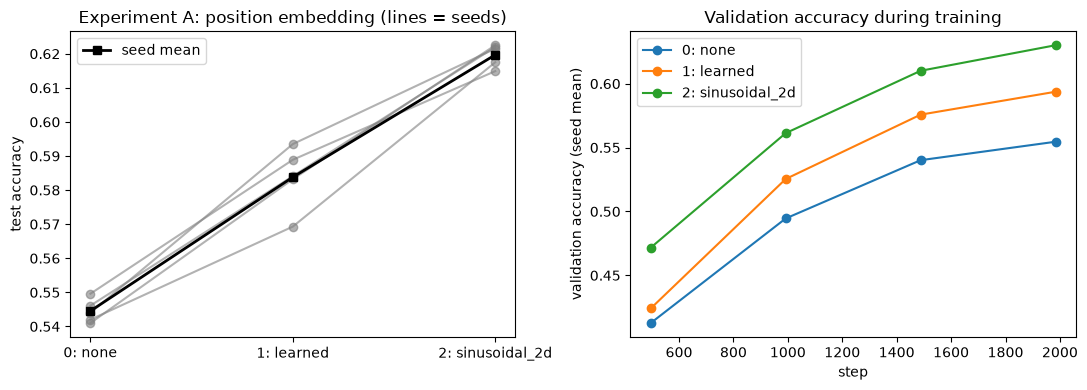

In [11]:
A_ACCURACY = np.array(
    [[test_accuracy(key_vit(STANDARD_PATCH_SIZE, pe, 1.0, s)) for s in SEEDS_A] for pe in POSITION_EMBEDDINGS]
)  # (3 条件, n_A)
_d = A_ACCURACY[1] - A_ACCURACY[0]
CONTRAST_A = {"value": float(_d.mean()), "sigma": float(_d.std(ddof=1) / math.sqrt(len(SEEDS_A)))}
verdict_A = judge(CONTRAST_A["value"], CONTRAST_A["sigma"])
precondition_status["P1(A)"] = bool((A_ACCURACY.mean(axis=1) >= ACCURACY_MIN).all())

print(f"{_tag}テスト正解率(行: 条件 0 なし・1 学習可能な 1 次元・2 の 2 次元正弦波、列: シード {SEEDS_A})")
for _c, _pe in enumerate(POSITION_EMBEDDINGS):
    _shuffled = np.array([RECORDS[key_vit(STANDARD_PATCH_SIZE, _pe, 1.0, s)]["shuffled_test"]["accuracy"] for s in SEEDS_A])
    _ce = np.array([RECORDS[key_vit(STANDARD_PATCH_SIZE, _pe, 1.0, s)]["test"]["cross_entropy"] for s in SEEDS_A])
    print(
        f"{_tag}  条件 {_c}({_pe}): {np.round(A_ACCURACY[_c], 4).tolist()} 平均 {A_ACCURACY[_c].mean():.4f}、"
        f"テストの交差エントロピー平均 {_ce.mean():.4f}、並べ替えたテスト画像の正解率 平均 {_shuffled.mean():.4f}"
        f"(低下幅 {(A_ACCURACY[_c] - _shuffled).mean():+.4f})"
    )
print(f"{_tag}d_s = a_1 - a_0: {np.round(_d, 4).tolist()}")
print(
    f"{_tag}対比量 Delta_A = {CONTRAST_A['value']:+.4f}、sigma_A = sd(d_s)/sqrt({len(SEEDS_A)}) = {CONTRAST_A['sigma']:.4f}、"
    f"閾値 2 sigma_A = {2 * CONTRAST_A['sigma']:.4f} -> 判定関数の結果: {verdict_A}"
)
print(
    f"{_tag}診断量(判定なし): 条件 2 - 条件 1 = {(A_ACCURACY[2] - A_ACCURACY[1]).mean():+.4f}"
    f"(シードごと {np.round(A_ACCURACY[2] - A_ACCURACY[1], 4).tolist()})"
)
print(
    f"{_tag}前提条件: P0(ViT) = {precondition_status['P0(ViT)']}、P1(A)(シード平均 >= {ACCURACY_MIN}) = "
    f"{precondition_status['P1(A)']}"
)

_fig, _axes = plt.subplots(1, 2, figsize=(11, 4))
for _s_i, _s in enumerate(SEEDS_A):
    _axes[0].plot(range(3), A_ACCURACY[:, _s_i], marker="o", color="gray", alpha=0.6)
_axes[0].plot(range(3), A_ACCURACY.mean(axis=1), marker="s", color="black", lw=2, label="seed mean")
_axes[0].set_xticks(range(3), [f"{i}: {pe}" for i, pe in enumerate(POSITION_EMBEDDINGS)])
_axes[0].set_ylabel("test accuracy")
_axes[0].set_title(f"{_plot_tag}Experiment A: position embedding (lines = seeds)")
_axes[0].legend()
_curve_steps = list(INTERMEDIATE_EVAL_STEPS) + [TRAIN_STEPS]
for _c, _pe in enumerate(POSITION_EMBEDDINGS):
    _curves = np.array(
        [
            [RECORDS[key_vit(STANDARD_PATCH_SIZE, _pe, 1.0, s)]["history"]["evaluations"][t]["val_accuracy"] for t in INTERMEDIATE_EVAL_STEPS]
            + [RECORDS[key_vit(STANDARD_PATCH_SIZE, _pe, 1.0, s)]["val"]["accuracy"]]
            for s in SEEDS_A
        ]
    )
    _axes[1].plot(_curve_steps, _curves.mean(axis=0), marker="o", label=f"{_c}: {_pe}")
_axes[1].set_xlabel("step")
_axes[1].set_ylabel("validation accuracy (seed mean)")
_axes[1].set_title("Validation accuracy during training")
_axes[1].legend()
plt.tight_layout()
plt.show()

### 6.8 観察: 位置埋め込みの類似度と注意距離(判定基準を設けない)

**判定基準を設けない観察である。** 実験 A のシード 0 のモデルについて、次を描く。

- 学習可能な 1 次元の位置埋め込み(条件 1)と 2 次元正弦波の位置埋め込み(条件 2、学習しない)の、パッチの位置どうしの余弦類似度。
  各小図は格子の 1 つの位置について、その位置の埋め込みと全位置の埋め込みの余弦類似度を $8 \times 8$ の格子に並べたもの
  (原論文の図 7 中央と同じ描き方)。学習可能な埋め込みに、同じ行・同じ列で類似度が高い 2 次元の構造が現れるかを見る。
- 層ごと・ヘッドごとの平均の注意距離(画素、検証集合の 1,000 枚)。原論文の図 7 右と同じ量で、下位層に局所的な(距離の小さい)
  ヘッドが現れるか、位置埋め込みの方式で違うかを見る。位置埋め込みなし(条件 0)では、パッチの配置を区別できないので、
  注意の重みは距離と無関係になるはずであり、平均の注意距離は全パッチの組の平均距離に近くなると予想される。

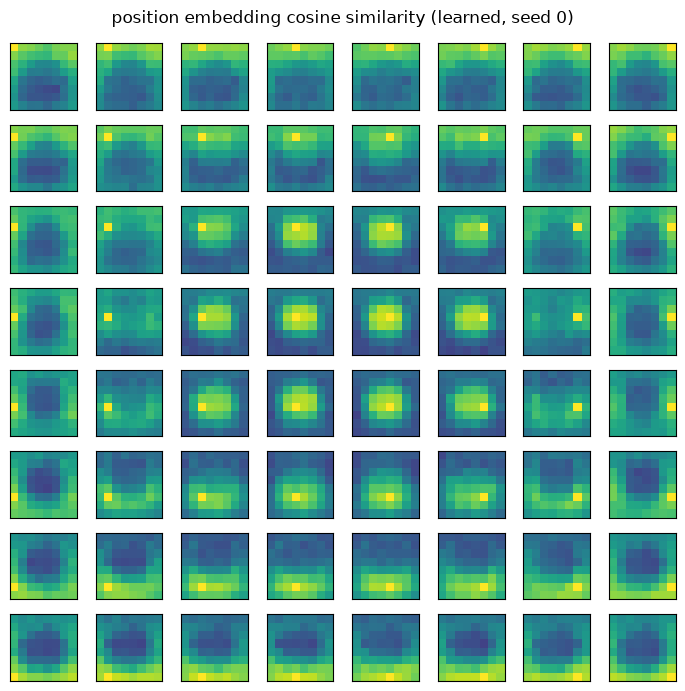

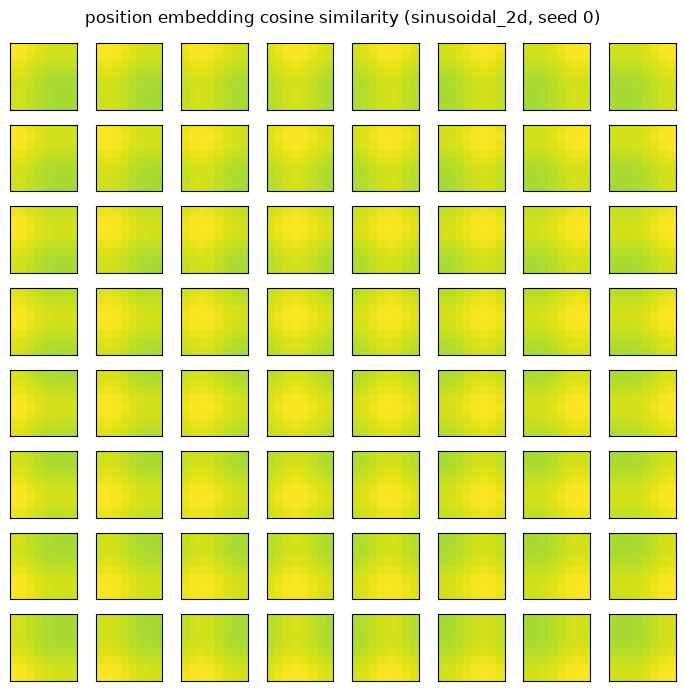

平均の注意距離(画素、行: 層、列: ヘッド)条件 0(none): [[15.08, 15.1, 14.57], [15.75, 16.03, 16.34], [15.94, 16.02, 16.13], [17.26, 15.89, 16.21], [16.5, 16.2, 16.02], [16.19, 16.65, 16.13]]
平均の注意距離(画素、行: 層、列: ヘッド)条件 1(learned): [[14.41, 14.39, 16.21], [15.23, 15.89, 15.77], [16.28, 16.65, 16.67], [15.96, 15.86, 16.24], [16.56, 16.04, 16.47], [16.46, 16.45, 16.52]]
平均の注意距離(画素、行: 層、列: ヘッド)条件 2(sinusoidal_2d): [[14.54, 12.83, 14.98], [13.48, 14.33, 13.8], [15.62, 17.71, 15.12], [17.35, 16.55, 17.41], [16.86, 16.64, 16.87], [16.32, 16.64, 16.11]]


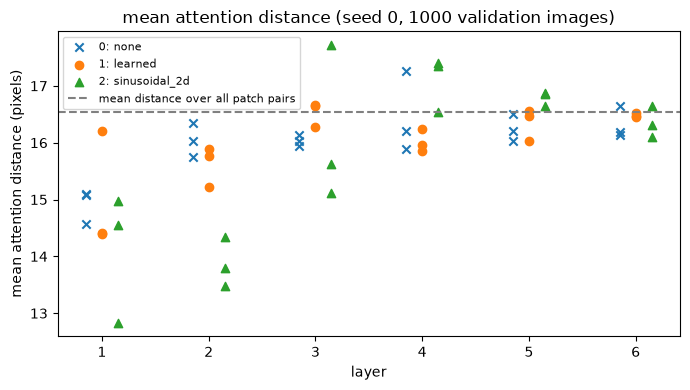

全パッチの組の平均距離: 16.55 画素


In [12]:
_grid = IMAGE_SIZE // STANDARD_PATCH_SIZE
for _pe in ("learned", "sinusoidal_2d"):
    _sim = RECORDS[key_vit(STANDARD_PATCH_SIZE, _pe, 1.0, 0)]["position_similarity"]
    _fig, _axes = plt.subplots(_grid, _grid, figsize=(7, 7))
    for _r in range(_grid):
        for _c in range(_grid):
            _axes[_r, _c].imshow(_sim[_r * _grid + _c].reshape(_grid, _grid), vmin=-1, vmax=1, cmap="viridis")
            _axes[_r, _c].set_xticks([])
            _axes[_r, _c].set_yticks([])
    _fig.suptitle(f"{_plot_tag}position embedding cosine similarity ({_pe}, seed 0)")
    plt.tight_layout()
    plt.show()

_rows, _cols = np.divmod(np.arange(_grid * _grid), _grid)
_all_pairs = STANDARD_PATCH_SIZE * np.sqrt((_rows[:, None] - _rows[None, :]) ** 2 + (_cols[:, None] - _cols[None, :]) ** 2)
_fig, _ax = plt.subplots(figsize=(7, 4))
for _c, (_pe, _marker) in enumerate(zip(POSITION_EMBEDDINGS, ("x", "o", "^"), strict=True)):
    _dist = RECORDS[key_vit(STANDARD_PATCH_SIZE, _pe, 1.0, 0)]["attention_distance"]  # (L, h)
    for _layer in range(NUM_LAYERS):
        _ax.scatter(
            [_layer + 1 + (_c - 1) * 0.15] * NUM_HEADS, _dist[_layer], marker=_marker, color=f"C{_c}",
            label=f"{_c}: {_pe}" if _layer == 0 else None,
        )
    print(f"{_tag}平均の注意距離(画素、行: 層、列: ヘッド)条件 {_c}({_pe}): {np.round(_dist.astype(np.float64), 2).tolist()}")
_ax.axhline(_all_pairs.mean(), color="gray", ls="--", label="mean distance over all patch pairs")
_ax.set_xlabel("layer")
_ax.set_ylabel("mean attention distance (pixels)")
_ax.set_title(f"{_plot_tag}mean attention distance (seed 0, {ATTENTION_DISTANCE_IMAGES} validation images)")
_ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"全パッチの組の平均距離: {_all_pairs.mean():.2f} 画素")

### 6.9 実験 B: パッチサイズと系列長

水準 P = (8, 4)(log2 N = [4.0, 6.0])
  P = 8(N = 16): テスト正解率 [0.4816, 0.4784, 0.4819, 0.4712, 0.4903] 平均 0.4807、交差エントロピー平均 1.4314
  P = 4(N = 64): テスト正解率 [0.5832, 0.5889, 0.5693, 0.5935, 0.5841] 平均 0.5838、交差エントロピー平均 1.1607
シードごとの傾き beta_s: [0.0508, 0.05525, 0.0437, 0.06115, 0.0469]
対比量 beta_bar = +0.05156(正解率 / log2 N)、sigma_B = sd(beta_s)/sqrt(5) = 0.00308、閾値 0.00616 -> 判定関数の結果: 支持
前提条件: P0(ViT) = True、P1(B) = True
診断量(判定なし): 計算量と 1 ステップの時間
  P = 8: 順伝播 92.8 MFLOP / 枚(P = 4 の 0.25 倍)、cuda での 1 ステップ 36.6 ms(P = 4 の 0.60 倍)
  P = 4: 順伝播 365.7 MFLOP / 枚(P = 4 の 1.00 倍)、cuda での 1 ステップ 60.7 ms(P = 4 の 1.00 倍)
  P = 2: 順伝播 1,669.8 MFLOP / 枚(P = 4 の 4.57 倍)、cuda での 1 ステップ 253.0 ms(P = 4 の 4.17 倍)(この段階では学習していない)


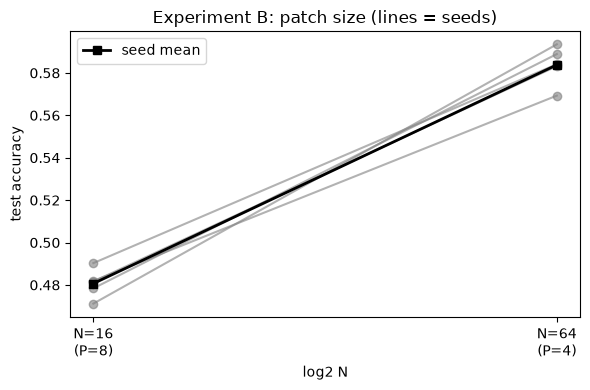

In [13]:
B_LOG2_N = np.array([math.log2((IMAGE_SIZE // p) ** 2) for p in B_PATCH_SIZES])
B_ACCURACY = np.array([[test_accuracy(key_vit(p, "learned", 1.0, s)) for p in B_PATCH_SIZES] for s in SEEDS_B])  # (n_B, 水準)
B_SLOPES = ols_slope(B_LOG2_N, B_ACCURACY)
CONTRAST_B = {"value": float(B_SLOPES.mean()), "sigma": float(B_SLOPES.std(ddof=1) / math.sqrt(len(SEEDS_B)))}
verdict_B = judge(CONTRAST_B["value"], CONTRAST_B["sigma"])
precondition_status["P1(B)"] = bool((B_ACCURACY.mean(axis=0) >= ACCURACY_MIN).all())

print(f"{_tag}水準 P = {B_PATCH_SIZES}(log2 N = {B_LOG2_N.tolist()})")
for _j, _p in enumerate(B_PATCH_SIZES):
    _ce = np.mean([RECORDS[key_vit(_p, "learned", 1.0, s)]["test"]["cross_entropy"] for s in SEEDS_B])
    print(
        f"{_tag}  P = {_p}(N = {(IMAGE_SIZE // _p) ** 2}): テスト正解率 {np.round(B_ACCURACY[:, _j], 4).tolist()} "
        f"平均 {B_ACCURACY[:, _j].mean():.4f}、交差エントロピー平均 {_ce:.4f}"
    )
print(f"{_tag}シードごとの傾き beta_s: {np.round(B_SLOPES, 5).tolist()}")
print(
    f"{_tag}対比量 beta_bar = {CONTRAST_B['value']:+.5f}(正解率 / log2 N)、sigma_B = sd(beta_s)/sqrt({len(SEEDS_B)}) = "
    f"{CONTRAST_B['sigma']:.5f}、閾値 {2 * CONTRAST_B['sigma']:.5f} -> 判定関数の結果: {verdict_B}"
)
print(f"{_tag}前提条件: P0(ViT) = {precondition_status['P0(ViT)']}、P1(B) = {precondition_status['P1(B)']}")
print("診断量(判定なし): 計算量と 1 ステップの時間")
for _p in PATCH_SIZES:
    _used = "" if _p in B_PATCH_SIZES else "(この段階では学習していない)"
    print(
        f"  P = {_p}: 順伝播 {VIT_FORWARD_FLOPS[_p] / 1e6:,.1f} MFLOP / 枚(P = 4 の {VIT_FORWARD_FLOPS[_p] / VIT_FORWARD_FLOPS[4]:.2f} 倍)、"
        f"{device} での 1 ステップ {STEP_SECONDS[f'vit_p{_p}'] * 1000:.1f} ms"
        f"(P = 4 の {STEP_SECONDS[f'vit_p{_p}'] / STEP_SECONDS['vit_p4']:.2f} 倍){_used}"
    )

_fig, _ax = plt.subplots(figsize=(6, 4))
for _s_i in range(len(SEEDS_B)):
    _ax.plot(B_LOG2_N, B_ACCURACY[_s_i], marker="o", color="gray", alpha=0.6)
_ax.plot(B_LOG2_N, B_ACCURACY.mean(axis=0), marker="s", color="black", lw=2, label="seed mean")
_ax.set_xticks(B_LOG2_N, [f"N={int(2**x)}\n(P={p})" for x, p in zip(B_LOG2_N, B_PATCH_SIZES, strict=True)])
_ax.set_xlabel("log2 N")
_ax.set_ylabel("test accuracy")
_ax.set_title(f"{_plot_tag}Experiment B: patch size (lines = seeds)")
_ax.legend()
plt.tight_layout()
plt.show()

### 6.10 実験 C: 帰納バイアスとデータ量

log2 f(実際の比)= [-4.0013, -2.0, 0.0]
  ViT f = 0.0625: テスト正解率 [0.4771, 0.4744, 0.4767] 平均 0.4761、交差エントロピー平均 1.9399、S_1/16 での正解率 平均 0.9081(テストとの差 +0.4320)
  ViT f = 0.2500: テスト正解率 [0.5735, 0.5717, 0.5757] 平均 0.5736、交差エントロピー平均 1.2011、S_1/16 での正解率 平均 0.6204(テストとの差 +0.0468)
  ViT f = 1.0000: テスト正解率 [0.5832, 0.5889, 0.5693] 平均 0.5805、交差エントロピー平均 1.1670、S_1/16 での正解率 平均 0.5877(テストとの差 +0.0072)
  ViT のシードごとの傾き gamma: [0.02652, 0.02862, 0.02315] 平均 +0.02609
  CNN f = 0.0625: テスト正解率 [0.6998, 0.7041, 0.6932] 平均 0.6990、交差エントロピー平均 1.7648、S_1/16 での正解率 平均 0.9995(テストとの差 +0.3005)
  CNN f = 0.2500: テスト正解率 [0.8104, 0.8035, 0.8048] 平均 0.8062、交差エントロピー平均 0.6354、S_1/16 での正解率 平均 0.9116(テストとの差 +0.1054)
  CNN f = 1.0000: テスト正解率 [0.8253, 0.8213, 0.8287] 平均 0.8251、交差エントロピー平均 0.5124、S_1/16 での正解率 平均 0.8463(テストとの差 +0.0212)
  CNN のシードごとの傾き gamma: [0.03137, 0.02929, 0.03387] 平均 +0.03151
対比量 Delta_C = gamma_ViT - gamma_CNN = -0.00541、sigma_C = sqrt(s_ViT^2/3 + s_CNN^2/3) = 0.00207、閾値 0.00414 -> 判定関数の結果: 反証
診断量(判定なし、天井効果の確認

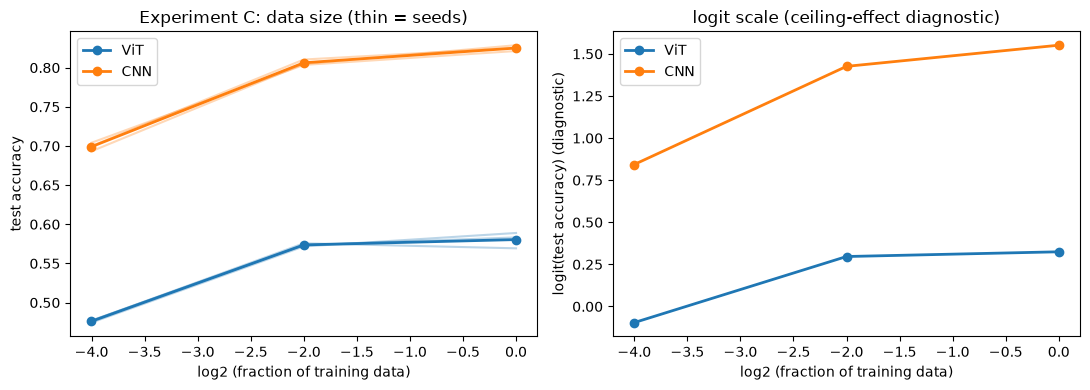

In [14]:
C_LOG2_F = np.array([math.log2(FRACTION_ACTUAL[f]) for f in DATA_FRACTIONS])
C_KEYS = {
    "ViT": lambda f, s: key_vit(STANDARD_PATCH_SIZE, "learned", f, s),
    "CNN": lambda f, s: key_cnn(f, s),
}
C_ACCURACY = {m: np.array([[test_accuracy(k(f, s)) for f in DATA_FRACTIONS] for s in SEEDS_C]) for m, k in C_KEYS.items()}
C_SLOPES = {m: ols_slope(C_LOG2_F, a) for m, a in C_ACCURACY.items()}


def slope_contrast(slopes: dict) -> dict:
    n = len(SEEDS_C)
    value = slopes["ViT"].mean() - slopes["CNN"].mean()
    sigma = math.sqrt(slopes["ViT"].var(ddof=1) / n + slopes["CNN"].var(ddof=1) / n)
    return {"value": float(value), "sigma": float(sigma)}


CONTRAST_C = slope_contrast(C_SLOPES)
verdict_C = judge(CONTRAST_C["value"], CONTRAST_C["sigma"])
precondition_status["P1(C)"] = bool(all((a.mean(axis=0) >= ACCURACY_MIN).all() for a in C_ACCURACY.values()))
_logit_slopes = {m: ols_slope(C_LOG2_F, logit(a)) for m, a in C_ACCURACY.items()}
_logit_contrast = slope_contrast(_logit_slopes)

print(f"{_tag}log2 f(実際の比)= {np.round(C_LOG2_F, 4).tolist()}")
for _m, _k in C_KEYS.items():
    for _j, _f in enumerate(DATA_FRACTIONS):
        _train_acc = np.array([RECORDS[_k(_f, s)]["common_subset_train_accuracy"] for s in SEEDS_C])
        _ce = np.mean([RECORDS[_k(_f, s)]["test"]["cross_entropy"] for s in SEEDS_C])
        print(
            f"{_tag}  {_m} f = {_f:.4f}: テスト正解率 {np.round(C_ACCURACY[_m][:, _j], 4).tolist()} 平均 {C_ACCURACY[_m][:, _j].mean():.4f}、"
            f"交差エントロピー平均 {_ce:.4f}、S_1/16 での正解率 平均 {_train_acc.mean():.4f}"
            f"(テストとの差 {(_train_acc - C_ACCURACY[_m][:, _j]).mean():+.4f})"
        )
    print(f"{_tag}  {_m} のシードごとの傾き gamma: {np.round(C_SLOPES[_m], 5).tolist()} 平均 {C_SLOPES[_m].mean():+.5f}")
print(
    f"{_tag}対比量 Delta_C = gamma_ViT - gamma_CNN = {CONTRAST_C['value']:+.5f}、"
    f"sigma_C = sqrt(s_ViT^2/{len(SEEDS_C)} + s_CNN^2/{len(SEEDS_C)}) = {CONTRAST_C['sigma']:.5f}、"
    f"閾値 {2 * CONTRAST_C['sigma']:.5f} -> 判定関数の結果: {verdict_C}"
)
print(
    f"{_tag}診断量(判定なし、天井効果の確認): ロジットの傾き ViT {_logit_slopes['ViT'].mean():+.4f}・CNN {_logit_slopes['CNN'].mean():+.4f}、"
    f"差 {_logit_contrast['value']:+.4f}(同じ式の sigma {_logit_contrast['sigma']:.4f}、比 {_logit_contrast['value'] / max(_logit_contrast['sigma'], 1e-12):+.2f})"
)
print(
    f"{_tag}前提条件: P0(ViT) = {precondition_status['P0(ViT)']}、P0(CNN) = {precondition_status['P0(CNN)']}、"
    f"P1(C) = {precondition_status['P1(C)']}"
)
print(
    f"交絡(5.4 節): パラメータ数 ViT {PARAMETER_TABLE['A: P=4, learned'][0]:,}・CNN {CNN_PARAMETERS:,}、"
    f"順伝播 ViT {VIT_FORWARD_FLOPS[4] / 1e6:,.0f} MFLOP・CNN {CNN_FORWARD_FLOPS / 1e6:,.0f} MFLOP / 枚"
)

_fig, _axes = plt.subplots(1, 2, figsize=(11, 4))
for _i, _m in enumerate(C_KEYS):
    for _s_i in range(len(SEEDS_C)):
        _axes[0].plot(C_LOG2_F, C_ACCURACY[_m][_s_i], color=f"C{_i}", alpha=0.3)
    _axes[0].plot(C_LOG2_F, C_ACCURACY[_m].mean(axis=0), marker="o", color=f"C{_i}", lw=2, label=_m)
    _axes[1].plot(C_LOG2_F, logit(C_ACCURACY[_m]).mean(axis=0), marker="o", color=f"C{_i}", lw=2, label=_m)
_axes[0].set_ylabel("test accuracy")
_axes[1].set_ylabel("logit(test accuracy) (diagnostic)")
for _ax in _axes:
    _ax.set_xlabel("log2 (fraction of training data)")
    _ax.legend()
_axes[0].set_title(f"{_plot_tag}Experiment C: data size (thin = seeds)")
_axes[1].set_title("logit scale (ceiling-effect diagnostic)")
plt.tight_layout()
plt.show()

### 6.11 不変条件のアサーションと`SMOKE_TEST`の配線

- すべての学習(較正を含む)で、ステップ数が $T$、学習率のスケジュールの形(最大値で割った列)が同一、データ拡張のパディングが同一。
- 本番の学習はすべて同じテスト集合 10,000 枚で評価した(テスト集合のテンソルが読み込み直後と一致)。較正の学習はテスト集合を
  評価していない。
- 同じシード・同じ部分集合の学習は、モデル・条件によらず、同じデータの順序・同じデータ拡張を使った(データの乱数の列のハッシュが
  一致)。
- 実験 A・B の ViT の非埋め込みパラメータ数が全学習で一致。
- 標準条件 S の記録を、実験 A の条件 1・実験 B の $P = 4$・実験 C の ViT の $f = 1$ で共有した(同じ鍵)。
- **`SMOKE_TEST`の配線**: 5.2 節・6.4 節で決まった実効値(水準・計画・$T$・段階・シード数・パッチサイズの水準・データ量の水準)が
  計画の表どおりであり、実際に使われた値(記録の鍵・学習の記録の長さ)と一致する。

In [15]:
_all_records = list(RECORDS.values()) + [r for c in CALIBRATION.values() for r in c["records"].values()]
_shape = None
for _r in _all_records:
    _h = _r["history"]
    assert _r["train_steps"] == TRAIN_STEPS and len(_h["loss"]) == TRAIN_STEPS and len(_h["learning_rate"]) == TRAIN_STEPS
    assert set(_h["evaluations"]) == set(INTERMEDIATE_EVAL_STEPS)
    assert _r["crop_padding"] == CROP_PADDING
    _normalized = np.array(_h["learning_rate"]) / _r["learning_rate"]
    _shape = _normalized if _shape is None else _shape
    assert np.allclose(_normalized, _shape, rtol=1e-12, atol=0), "学習率のスケジュールの形が異なる"
for _r in RECORDS.values():
    assert _r["purpose"] == "main" and _r["test"]["num_examples"] == len(TEST_LABELS)
for _c in CALIBRATION.values():
    assert all(r["purpose"] == "calibration" and "test" not in r for r in _c["records"].values())
assert sha256_of_tensor(TEST_IMAGES) == TEST_IMAGES_SHA256
_streams: dict = {}
for _r in RECORDS.values():
    _streams.setdefault((_r["key"][4], _r["key"][3]), set()).add(_r["history"]["data_stream_hash"])
assert all(len(v) == 1 for v in _streams.values()), "同じシード・同じ部分集合でデータの順序・拡張が異なる"
_vit_non_embedding = {r["non_embedding_parameters"] for r in RECORDS.values() if r["key"][0] == "vit"}
assert _vit_non_embedding == {NON_EMBEDDING_PARAMETERS}
for _s in SEEDS_S:  # S は 1 つの記録を共有する
    assert key_vit(STANDARD_PATCH_SIZE, "learned", 1.0, _s) in RECORDS
assert set(SEEDS_S) >= set(SEEDS_A) | set(SEEDS_B) | set(SEEDS_C)
print(
    f"不変条件: 全 {len(_all_records)} 学習(本番 {len(RECORDS)}・較正 {len(_all_records) - len(RECORDS)})の T = {TRAIN_STEPS}・"
    f"学習率のスケジュールの形・パディングが同一、本番はすべて同じテスト集合 {len(TEST_LABELS):,} 枚で評価、較正はテスト集合を評価していない、"
    f"同じシード・同じ部分集合のデータの順序と拡張が共通({len(_streams)} 組)、ViT の非埋め込みパラメータ数が一致、S を共有: OK"
)

_table = PLANS[CURRENT_LEVEL_NAME][SELECTED_PLAN]
assert _table["plan"] == SELECTED_PLAN and _table["T"] == TRAIN_STEPS and _table["stage"] == SELECTED_STAGE
assert TRAIN_STEPS == T_CANDIDATES[CURRENT_LEVEL_NAME][SELECTED_PLAN // 4] and SELECTED_STAGE == SELECTED_PLAN % 4
_effective = {
    "level": CURRENT_LEVEL_NAME,
    "plan": SELECTED_PLAN,
    "stage": SELECTED_STAGE,
    "train_steps": TRAIN_STEPS,
    "seeds": {k[-1]: STAGES[CURRENT_LEVEL_NAME][_table["stage"]][k] for k in SEED_KEYS},
    "b_patch_sizes": list(STAGES[CURRENT_LEVEL_NAME][_table["stage"]]["B_PATCH_SIZES"]),
    "fractions": list(DATA_FRACTIONS),
    "runs": len(plan_runs(STAGES[CURRENT_LEVEL_NAME][_table["stage"]])),
}
_history_lengths = {len(r["history"]["loss"]) for r in _all_records}
assert len(_history_lengths) == 1
_used = {
    "level": CURRENT_LEVEL_NAME,
    "plan": SELECTED_PLAN,
    "stage": SELECTED_STAGE,
    "train_steps": _history_lengths.pop(),
    "seeds": {
        "A": len({k[4] for k in RECORDS if k[0] == "vit" and k[2] == "none"}),
        "B": len({k[4] for k in RECORDS if k[0] == "vit" and k[1] == max(B_PATCH_SIZES)}),
        "C": len({k[4] for k in RECORDS if k[0] == "cnn"}),
    },
    "b_patch_sizes": sorted({k[1] for k in RECORDS if k[0] == "vit"}, reverse=True),
    "fractions": sorted({k[3] for k in RECORDS}),
    "runs": len(RECORDS),
}
assert _used == _effective, (_used, _effective)
assert (CURRENT_LEVEL_NAME == "smoke") == SMOKE_TEST
assert A_ACCURACY.shape == (3, len(SEEDS_A)) and B_ACCURACY.shape == (len(SEEDS_B), len(B_PATCH_SIZES))
assert all(a.shape == (len(SEEDS_C), len(DATA_FRACTIONS)) for a in C_ACCURACY.values())
print(f"SMOKE_TEST={SMOKE_TEST} の配線: 実効値 {json.dumps(_effective)} と実際に使われた値が一致: OK")

不変条件: 全 43 学習(本番 35・較正 8)の T = 1984・学習率のスケジュールの形・パディングが同一、本番はすべて同じテスト集合 10,000 枚で評価、較正はテスト集合を評価していない、同じシード・同じ部分集合のデータの順序と拡張が共通(11 組)、ViT の非埋め込みパラメータ数が一致、S を共有: OK
SMOKE_TEST=False の配線: 実効値 {"level": "prod", "plan": 6, "stage": 2, "train_steps": 1984, "seeds": {"A": 5, "B": 5, "C": 3}, "b_patch_sizes": [8, 4], "fractions": [0.0625, 0.25, 1.0], "runs": 35} と実際に使われた値が一致: OK


### 6.12 判定結果の一覧

前提条件が 1 つでも不成立の実験は、判定関数の結果に関わらず「前提不成立」とする(判定不能とは区別する)。判定関数の結果は
参考として別欄に残す。選ばれた計画($T$・段階)と、判定に実際に使ったシード数・水準を印字する。

In [16]:
def verdict_label(computed: str, preconditions: list[str]) -> str:
    return computed if all(precondition_status.get(p) for p in preconditions) else "前提不成立"


print(f"{_tag}計画の選択: {PLAN_SELECTION_MESSAGE}")
print(
    f"{_tag}判定に使った値: 計画 {SELECTED_PLAN}(T = {TRAIN_STEPS}、段階 {SELECTED_STAGE})、学習率 ViT {LEARNING_RATE['vit']:g}・CNN {LEARNING_RATE['cnn']:g}、"
    f"n_A = {len(SEEDS_A)}、n_B = {len(SEEDS_B)}(P {B_PATCH_SIZES})、n_C = {len(SEEDS_C)}(f {DATA_FRACTIONS})"
)
_rows = [
    ("A", f"Delta_A = {CONTRAST_A['value']:+.4f}(sigma {CONTRAST_A['sigma']:.4f})", ["P0(ViT)", "P1(A)"], verdict_A),
    ("B", f"beta_bar = {CONTRAST_B['value']:+.5f}(sigma {CONTRAST_B['sigma']:.5f})", ["P0(ViT)", "P1(B)"], verdict_B),
    ("C", f"Delta_C = {CONTRAST_C['value']:+.5f}(sigma {CONTRAST_C['sigma']:.5f})", ["P0(ViT)", "P0(CNN)", "P1(C)"], verdict_C),
]
print(f"{_tag}実験 | 対比量 | 前提条件 | 判定関数の結果 | 最終判定")
for _name, _value, _pre, _computed in _rows:
    print(
        f"{_tag}{_name} | {_value} | "
        + ", ".join(f"{p}={precondition_status.get(p)}" for p in _pre)
        + f" | {_computed} | {verdict_label(_computed, _pre)}"
    )
print(f"\nノートブック全体の実行時間: {(time.time() - NOTEBOOK_START_TIME) / 60:.1f} 分")

計画の選択: 残りの予算 98.8 分に収まる番号の最も小さい計画として、計画 6 を選んだ(見積もり 82.7 分、cuda 基準)
判定に使った値: 計画 6(T = 1984、段階 2)、学習率 ViT 0.0005・CNN 0.004、n_A = 5、n_B = 5(P (8, 4))、n_C = 3(f (0.0625, 0.25, 1.0))
実験 | 対比量 | 前提条件 | 判定関数の結果 | 最終判定
A | Delta_A = +0.0393(sigma 0.0036) | P0(ViT)=True, P1(A)=True | 支持 | 支持
B | beta_bar = +0.05156(sigma 0.00308) | P0(ViT)=True, P1(B)=True | 支持 | 支持
C | Delta_C = -0.00541(sigma 0.00207) | P0(ViT)=True, P0(CNN)=False, P1(C)=True | 反証 | 前提不成立

ノートブック全体の実行時間: 106.6 分


## 7. 結果・考察 / Results and Discussion

**本番実行(Google Colab T4)の後に、セル出力と突き合わせて記述する。** 以下は各節に何を書くかの一覧である。判定は 6.1 節で
事前に宣言した基準のみから導き、結果を見た後に立てた解釈は 7.6 節に分けて記す。

### 7.1 実行の概要

- 実行環境(5.1 節の印字: GPU・torch・CUDA・コミット・実行日時)と混合精度の実効設定。
- データの準備の時間(CIFAR-10 のダウンロードを含む)、画素が完全に一致する画像の重複の数(5.3 節)。
- スケーリングの計測(6.3 節)・12 通りの計画の見積もりと **選ばれた計画・$T$・段階**(6.4 節)、実際の実行時間と見積もりの比較。
- 学習率の較正の結果(6.5 節): 格子の各点の検証正解率、拡張の有無、選ばれた学習率、P0。
- 損失スケーリングで飛ばしたステップの数(6.6 節の各行)。

### 7.2 前提条件

- P0(ViT・CNN)・P1(A・B・C)の値と成否の表。

### 7.3 実験 A: 位置埋め込みの寄与

- 3 条件のテスト正解率、$\Delta_A$・$\sigma_A$・判定。
- 診断量: 並べ替えたテスト画像での正解率と低下幅(位置情報への依存度)、条件 2 と条件 1 の差、検証正解率の推移。
- 観察(6.8 節、判定なし): 位置埋め込みの類似度の図に 2 次元の構造が現れたか、平均の注意距離の層ごとの傾向と条件間の違い。

### 7.4 実験 B: パッチサイズと系列長

- 各水準のテスト正解率、$\bar{\beta}$・$\sigma_B$・判定(選ばれた段階で $P = 2$ を含んだかどうか)。
- 診断量: 計算量と 1 ステップの時間の比(交絡の大きさ)、中央の水準の位置(曲線の形)。

### 7.5 実験 C: 帰納バイアスとデータ量

- ViT・CNN の各データ量のテスト正解率、$\gamma$ の平均、$\Delta_C$・$\sigma_C$・判定。
- 診断量: ロジットの傾きの差(天井効果の有無)、$S_{1/16}$ での正解率とテスト正解率の差(汎化の差)、パラメータ数・計算量の交絡。

### 7.6 事後的な解釈(検証済みの結論ではない)

- 想定と異なる結果があれば、結果を見た後の解釈をここに分けて記す。

### 7.7 まとめ

- 判定の一覧と、本トピックの規模(CIFAR-10)から言えること・言えないこと。原論文の大規模な事前学習の主張との関係。
- **選ばれた $T$ から言えること・言えないこと**: 全データで何エポック学習したか、学習曲線(検証正解率の推移)が $T$ の時点で
  飽和していたか。飽和していなければ、実験 C は「十分に学習した状態での汎化の差」ではなく学習の途中の比較であり、その限定を
  結論に付ける。$T$ が候補の最大値より小さかった場合は、その理由(T4 の見積もり)と、より大きな $T$ で結論が変わりうることを記す。

### 本番実行の後に更新が必要な箇所

- 7 節の全体(上の箇条書きを、本番のセル出力に基づく本文に置き換える)。
- 1 節の概要に結果の要約を追記する。
- `theories/README.md`の 019 の行に本番の結果の要約を追記する。
- 選ばれた計画・$T$・段階(6.4 節の出力)を、1 節の概要・7.1 節・`theories/README.md`の 019 の行に記す(6.2 節の本文は、本番前に
  書いた根拠として変更しない)。